In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import os
import numpy as np
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.stats import mannwhitneyu, false_discovery_control
import re
from itertools import combinations
from scipy.stats import pearsonr
from matplotlib import patches
import ast

In [2]:
def stack_triangle(df, col):
    df = pd.DataFrame(
        df.where(
            np.tri(
                df.shape[0],
                dtype=bool,
                k=-1
            ),
            np.nan
        ).stack(dropna=True), columns=[col] 
    )
    
    return df


In [3]:
# Function that generates and saves the ROC curve
def generate_roc_curve(
    data,
    target_col,
    feature_col,
):
    # ROC curve using all gene pairs
    fpr, tpr, thr = roc_curve(data[target_col], data[feature_col])
    auroc = roc_auc_score(data[target_col], data[feature_col])
    
    return fpr, tpr, thr, auroc

In [4]:
def fig_to_panels(fig, axes, output_dir):
    # Save individual panels of a figure 
    
    for panel_name, ax in axes.items():
        # Extract the panel title
        panel_title = ax.get_title()

        # Sanitize the panel title to use in filenames
        safe_title = panel_title.replace(" ", "_").replace("/", "_").replace("\n", "_").lower()

        # Create the filename for the current panel
        output_file = os.path.join(output_dir,safe_title)

        # Adjust the bounding box to include everything (labels, titles, etc.)
        extent = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

        # Save the individual panel using the adjusted bounding box
        fig.savefig(output_file + '.pdf', bbox_inches=extent, dpi=300)
        fig.savefig(output_file + '.png', bbox_inches=extent)

        print(f"Saved panel '{panel_title}' to {output_file}")


In [5]:
# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

In [6]:
def network_to_adj(network_path):
    network = pd.read_csv(
        network_path,
        usecols=['complex1', 'complex2', 'adj']
    )

    # Add a mirrored version of the network to make it symmetric
    network_mirrored = network.copy()
    network_mirrored.columns = ['complex2', 'complex1', 'adj']
    network = pd.concat([network, network_mirrored], ignore_index=True)

    adj = network.pivot(index='complex1', columns='complex2', values='adj').fillna(0)
    return adj

In [7]:
# Load hallmark gene sets
def read_gmt(file_path):
    gene_sets = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                gene_sets[parts[0]] = set(parts[2:])
    return gene_sets

hallmarks_path = '/home/lnemati/resources/msigdb_hallmarks/h.all.v2024.1.Hs.symbols.gmt'
hallmarks = read_gmt(hallmarks_path)

In [8]:
from itertools import combinations

# Calculate Jaccard Index between all pairs
overlap_stats = []

for (name1, genes1), (name2, genes2) in combinations(hallmarks.items(), 2):
    intersection = genes1 & genes2
    union = genes1 | genes2
    jaccard_index = len(intersection) / len(union) if union else 0
    overlap_stats.append({
        'set1': name1,
        'set2': name2,
        'jaccard': jaccard_index,
        'intersection_size': len(intersection)
    })

# Sort by Jaccard index descending
overlap_stats_sorted = sorted(overlap_stats, key=lambda x: x['jaccard'], reverse=True)

# Print top 10 pairs
for stat in overlap_stats_sorted[:10]:
    print(f"{stat['set1']} ↔ {stat['set2']}: Jaccard = {stat['jaccard']:.3f}, "
          f"Shared Genes = {stat['intersection_size']}")


HALLMARK_ESTROGEN_RESPONSE_EARLY ↔ HALLMARK_ESTROGEN_RESPONSE_LATE: Jaccard = 0.338, Shared Genes = 101
HALLMARK_INTERFERON_ALPHA_RESPONSE ↔ HALLMARK_INTERFERON_GAMMA_RESPONSE: Jaccard = 0.326, Shared Genes = 73
HALLMARK_E2F_TARGETS ↔ HALLMARK_G2M_CHECKPOINT: Jaccard = 0.223, Shared Genes = 73
HALLMARK_BILE_ACID_METABOLISM ↔ HALLMARK_PEROXISOME: Jaccard = 0.220, Shared Genes = 39
HALLMARK_COAGULATION ↔ HALLMARK_COMPLEMENT: Jaccard = 0.203, Shared Genes = 57
HALLMARK_GLYCOLYSIS ↔ HALLMARK_HYPOXIA: Jaccard = 0.194, Shared Genes = 65
HALLMARK_INFLAMMATORY_RESPONSE ↔ HALLMARK_TNFA_SIGNALING_VIA_NFKB: Jaccard = 0.146, Shared Genes = 51
HALLMARK_NOTCH_SIGNALING ↔ HALLMARK_WNT_BETA_CATENIN_SIGNALING: Jaccard = 0.121, Shared Genes = 8
HALLMARK_ADIPOGENESIS ↔ HALLMARK_OXIDATIVE_PHOSPHORYLATION: Jaccard = 0.114, Shared Genes = 41
HALLMARK_G2M_CHECKPOINT ↔ HALLMARK_MITOTIC_SPINDLE: Jaccard = 0.108, Shared Genes = 39


# Immunotherapy Prediction

In [9]:
## Read the results
cohorts_dir = '/home/lnemati/pathway_crosstalk/results/immunotherapy/features_sets/tissues'

dfs = []

for cohort in os.listdir(cohorts_dir):
    path = os.path.join(cohorts_dir, cohort, 'metrics')
    for file in os.listdir(path):
        metricsdf = pd.read_csv(os.path.join(path, file))
        metricsdf.columns = ['type'] + list(metricsdf.columns[1:])
        metricsdf['cohort'] = cohort
        
        probs_path = os.path.join(cohorts_dir, cohort, 'prediction_probabilities')
        probs = pd.read_csv(os.path.join(probs_path, 'whole_transcriptome.csv'), index_col=0)
        metricsdf['n_patients'] = probs.shape[1]
        
        dfs.append(metricsdf)
        
metricsdf = pd.concat(dfs, ignore_index=True)

In [10]:
import os
import pandas as pd
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

cohorts_dir = '/home/lnemati/pathway_crosstalk/results/immunotherapy/features_sets/tissues'

roc_curves = {}
pr_curves = {}

for cohort in os.listdir(cohorts_dir):
    path = os.path.join(cohorts_dir, cohort, 'prediction_probabilities')
    
    roc_curves[cohort] = {}
    pr_curves[cohort] = {}

    for file in os.listdir(path):
        ftype = file.replace('.csv', '')
        roc_curves[cohort][ftype] = {}
        pr_curves[cohort][ftype] = {}

        tmp = pd.read_csv(os.path.join(path, file), index_col=0)

        # Convert true labels to binary (1 for 'R', 0 for 'N')
        y_true = tmp.iloc[0].map({'R': 1, 'N': 0}).values  
        y_score = tmp.iloc[1].astype(float).values  # Ensure probabilities are floats

        # Compute ROC Curve
        fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
        roc_curves[cohort][ftype]['fpr'] = fpr
        roc_curves[cohort][ftype]['tpr'] = tpr
        roc_curves[cohort][ftype]['thresholds'] = roc_thresholds
        roc_curves[cohort][ftype]['auc'] = roc_auc_score(y_true, y_score)

        # Compute Precision-Recall Curve
        precision, recall, pr_thresholds = precision_recall_curve(y_true, y_score)
        pr_curves[cohort][ftype]['precision'] = precision
        pr_curves[cohort][ftype]['recall'] = recall
        pr_curves[cohort][ftype]['thresholds'] = pr_thresholds
        pr_curves[cohort][ftype]['auprc'] = average_precision_score(y_true, y_score)


In [11]:
order_labels_dict = {
    'cd274': 'CD274',
    'tls-melanoma': 'TLS-Melanoma',
    'caf_pca': 'CAF (PCA)',
    't_cell_dysfunction_pca': 'T Cell Dysfunction (PCA)',
    'mdsc_pca': 'MDSC (PCA)',
    'ifng': 'IFNG',
    'tam_m2_pca': 'TAM M2 (PCA)',
    'cd8': 'CD8',
    'whole_transcriptome': 'All Genes (PCA)',
    't_cell_exclusion_pca': 'T Cell Exclusion (PCA)',
    'all_ccis': 'All CCIs (PCA)',
    #'all_signatures': 'All Signatures',
    'tls': 'TLS',
    't_cell-inflamed_gep': 'T Cell-Inflamed GEP',
    #'all_motifs': 'All Motifs',
    'all_cliques': 'Cliques'
}

order = []
features_labels = []

baseline = metricsdf.query('type == "whole_transcriptome" and cohort != "full_dataset"')['auroc'].mean()

for idx in metricsdf.groupby('type')['auroc'].mean().sort_values().index:
    if metricsdf.query('type == @idx and cohort != "full_dataset"')['auroc'].mean() >= baseline:
        if idx in order_labels_dict.keys():
            order.append(idx)
            features_labels.append(order_labels_dict[idx])

#for idx in metricsdf.query('cohort != "full_dataset"').groupby('type')['auroc'].median().sort_values().index:
#    if idx in order_labels_dict.keys():
#        order.append(idx)
#        features_labels.append(order_labels_dict[idx])

/var/tmp/pbs.436024.pbs01/ipykernel_292477/1750519579.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/var/tmp/pbs.436024.pbs01/ipykernel_292477/1750519579.py:35: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(
/var/tmp/pbs.436024.pbs01/ipykernel_292477/1750519579.py:35: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(
/var/tmp/pbs.436024.pbs01/ipykernel_292477/1750519579.py:63: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/var/tmp/pbs.436024.pbs01/ipykernel_292477/1750519579.py:63: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(
/var/tmp/pbs.436024.pbs01/ipykernel

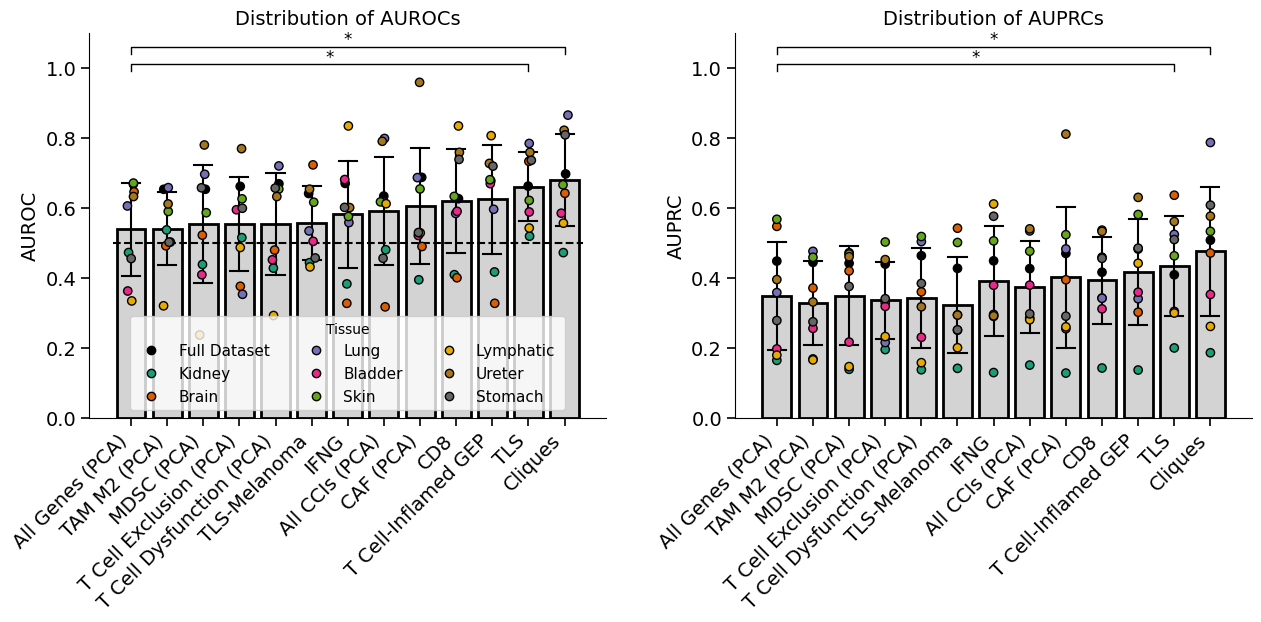

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

fs = 14  # Font size
smallfs = 11

# Compute differences
def compute_differences(df):
    df = df.copy()
    whole_transcriptome_values = df[df["type"] == "whole_transcriptome"].set_index("cohort")["auroc"]
    df["auroc_diff"] = df.apply(lambda row: row["auroc"] - whole_transcriptome_values[row["cohort"]], axis=1)
    whole_transcriptome_values = df[df["type"] == "whole_transcriptome"].set_index("cohort")["auprc"]
    df["auprc_diff"] = df.apply(lambda row: row["auprc"] - whole_transcriptome_values[row["cohort"]], axis=1)
    return df

df_diff = compute_differences(metricsdf)

# Setup figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
plt.subplots_adjust(wspace=0.25)

# Get unique cohorts excluding full_dataset
cohorts = [c for c in df_diff.cohort.unique() if c != "full_dataset"]
colors = sns.color_palette("Dark2", len(cohorts))
cohort_colors = dict(zip(cohorts, colors))
cohort_colors['full_dataset'] = 'black'

# AUROC subplot (Left)
ax1 = axes[0]
#sns.boxplot(df.query('cohort != "full_dataset"'), x='type', y='auroc', color='lightgray', boxprops={"alpha": 0.7}, ax=ax1, order=order)

sns.barplot(
    data=metricsdf,
    x='type',
    y='auroc',
    estimator='mean',
    ci='sd',
    color='lightgray',
    ax=ax1,
    order=order,
    errcolor='black',
    errwidth=1.5,
    capsize=0.5,
    lw=2,
    edgecolor='k',
)
sns.stripplot(metricsdf, x='type', y='auroc', hue='cohort', palette=cohort_colors, jitter=True, size=6, edgecolor="black", linewidth=1., ax=ax1, order=order)

ax1.hlines(0.5, *ax1.get_xlim(), color='k', linestyle='--')
#ax1.set_title("AUROC", fontsize=fs)
ax1.set_xlabel("Features Set", fontsize=fs)
ax1.set_ylabel("AUROC", fontsize=fs)
ax1.set_title('Distribution of AUROCs', fontsize=fs)


# AUPRC subplot (Right)
ax2 = axes[1]
#sns.boxplot(metricsdf.query('cohort != "full_dataset"'), x='type', y='auprc', color='lightgray', boxprops={"alpha": 0.7}, ax=ax2, order=order)

sns.barplot(
    data=metricsdf,
    x='type',
    y='auprc',
    estimator='mean',
    ci='sd',
    color='lightgray',
    ax=ax2,
    order=order,
    errcolor='black',
    errwidth=1.5,
    capsize=0.5,
    lw=2,
    edgecolor='k',
)
sns.stripplot(metricsdf, x='type', y='auprc', hue='cohort', palette=cohort_colors, jitter=False, size=6, edgecolor="black", linewidth=1., ax=ax2, order=order)

#ax2.set_title("AUPRC", fontsize=fs)
ax2.set_xlabel("Features Set", fontsize=fs)
ax2.set_ylabel("AUPRC", fontsize=fs)
ax2.set_title('Distribution of AUPRCs', fontsize=fs)

ax2.get_legend().remove()

#fig.suptitle('Distribution of AUROCs and AUPRCs Across Features Sets', fontsize=fs, )

# Compute p-values for AUROC and AUPRC separately
p_values_auroc = []
p_values_auprc = []
comparisons = []
reference_group = "whole_transcriptome"

for group in order:
    if group == reference_group:
        continue
    stat_auroc, p_auroc = wilcoxon(df_diff.query(f'type == "{group}"')["auroc_diff"], alternative='greater')
    stat_auprc, p_auprc = wilcoxon(df_diff.query(f'type == "{group}"')["auprc_diff"], alternative='greater')
    
    if p_auroc < 0.05 or p_auprc < 0.05:
        p_values_auroc.append(p_auroc)
        p_values_auprc.append(p_auprc)
        comparisons.append(group)

# Function to convert p-values to significance stars
def get_significance_label(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

pval_labels_auroc = {group: get_significance_label(p) for group, p in zip(comparisons, p_values_auroc)}
pval_labels_auprc = {group: get_significance_label(p) for group, p in zip(comparisons, p_values_auprc)}

ax1.set_ylim(bottom=0, top=1.1)
ax2.set_ylim(bottom=0, top=1.1)
ax1.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

# Function to add significance bars
def add_significance_bars(ax, pval_labels, comparisons, y_offset=0.05, text_offset=0.02):
    y_max = 0.9*ax.get_ylim()[1]
    bar_height = (y_max - ax.get_ylim()[0]) * 0.02
    
    for i, group in enumerate(comparisons):
        sig_label = pval_labels[group]
        x1, x2 = order.index(reference_group), order.index(group)
        y = y_max + (2.5 * i * bar_height)

        ax.plot([x1, x1, x2, x2], [y, y + bar_height, y + bar_height, y], lw=1, linestyle='-', color="black")
        ax.text(0.5 * (x1 + x2), y + 1.3 * bar_height, sig_label, ha='center', fontsize=12)

# Add significance bars
add_significance_bars(ax1, pval_labels_auroc, comparisons)
add_significance_bars(ax2, pval_labels_auprc, comparisons)

# Adjust x-labels
for ax in axes:
    ax.set_xticklabels(features_labels, rotation=45, ha='right')
    ax.set_xlabel('')
    ax.tick_params(labelsize=fs)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles, legend_labels = ax1.get_legend_handles_labels()
ax1.legend(
    handles,
    [label.title().replace('_', ' ').replace('Tissue', '') for label in legend_labels],
    title="Tissue",
    ncol=3,
    fontsize=smallfs,
    loc='lower center'
)

for ax in (ax1, ax2):
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.get_xaxis().set_visible(True)
    ax.get_yaxis().set_visible(True)
    
    ax.tick_params(
        axis='both',
        which='both',
        labelsize=fs,
        direction='out',
        length=6,
        width=1.2,
        colors='black'
    )
    
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/immunotherapy/auroc_auprc_barplot.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/immunotherapy/auroc_auprc_barplot.png', bbox_inches='tight', dpi=300)

plt.show()

/var/tmp/pbs.436024.pbs01/ipykernel_292477/2326903532.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(features_labels, rotation=45, ha='right')
/var/tmp/pbs.436024.pbs01/ipykernel_292477/2326903532.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(features_labels, rotation=45, ha='right')


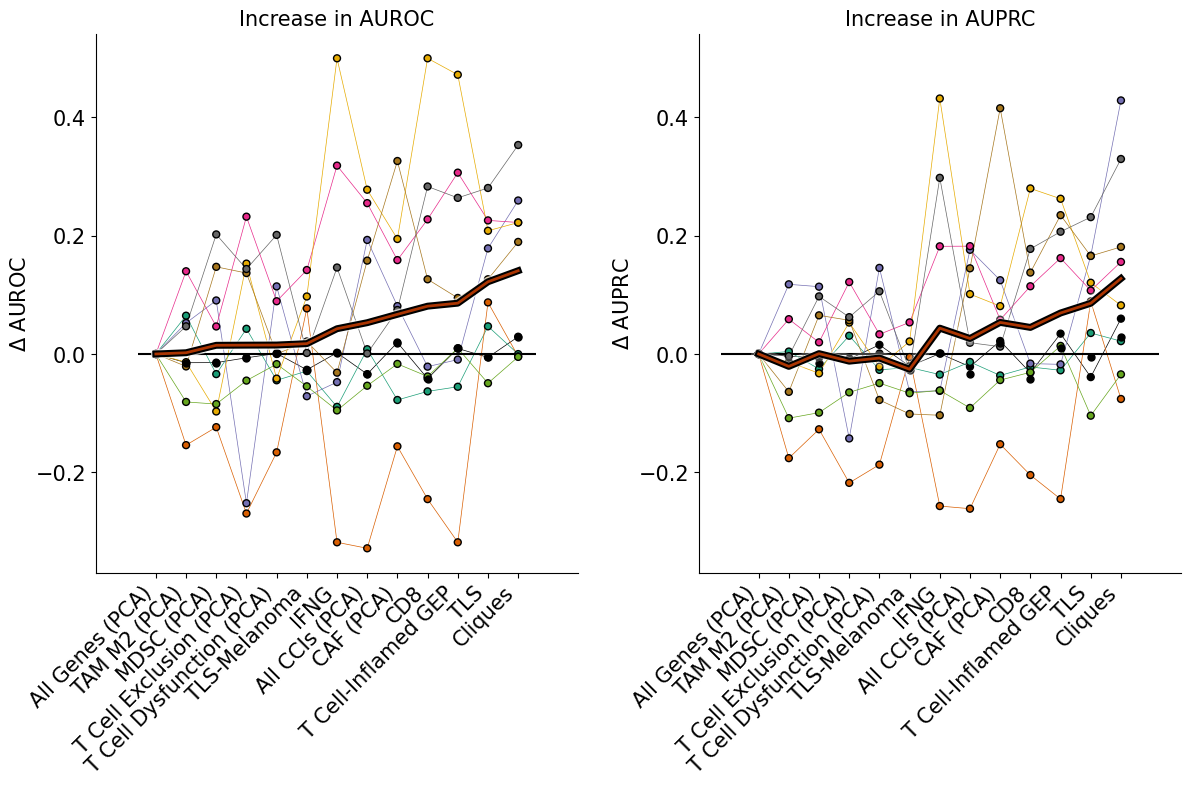

In [13]:
import matplotlib.patheffects as pe

# Setup figure with only two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True)
plt.subplots_adjust(wspace=0.25)
fs = 15  # Font size
alpha=1

ax3, ax4 = axes  # Assign the two axes

# AUROC Difference subplot (Left)
sns.stripplot(df_diff, x='type', y='auroc_diff', hue=df_diff['cohort'], palette=cohort_colors, 
              jitter=False, size=5, edgecolor="black", linewidth=1., alpha=alpha, ax=ax3, order=order)
sns.stripplot(df_diff.query('cohort == "full_dataset"'), x='type', y='auroc_diff', color='black', 
              jitter=False, size=5, edgecolor="black", linewidth=1., alpha=alpha, ax=ax3, order=order)

for cohort in df_diff.cohort.unique():
    ax3.plot(df_diff.query('cohort == @cohort').set_index('type').reindex(order)['auroc_diff'], 
             color=cohort_colors.get(cohort, 'black'), linestyle='-', alpha=alpha, lw=0.5)

# Mean AUROC difference line
mean_auroc = df_diff.groupby('type')['auroc_diff'].mean().reindex(order)

ax3.plot(
    order,
    mean_auroc,
    color=tcolor,  # This will stay fully visible
    linewidth=2,
    linestyle='-',
    path_effects=[
        pe.Stroke(linewidth=7, foreground='white', alpha=0.7),   # Outer soft white halo
        pe.Stroke(linewidth=5, foreground='black', alpha=1),     # Inner solid black halo
        pe.Normal()                                              # Actual line on top
    ],
    label='Mean',
    zorder=10
)

ax3.hlines(0, *ax3.get_xlim(), color='k', linestyle='-')
ax3.set_ylabel(r"$\Delta$ AUROC", fontsize=fs)

# AUPRC Difference subplot (Right)
sns.stripplot(df_diff, x='type', y='auprc_diff', hue=df_diff['cohort'], palette=cohort_colors, 
              jitter=False, size=5, edgecolor="black", linewidth=1., alpha=alpha, ax=ax4, order=order)
sns.stripplot(df_diff.query('cohort == "full_dataset"'), x='type', y='auroc_diff', color='black', 
              jitter=False, size=5, edgecolor="black", linewidth=1., alpha=alpha, ax=ax4, order=order)

for cohort in df_diff.cohort.unique():
    ax4.plot(df_diff.query('cohort == @cohort').set_index('type').reindex(order)['auprc_diff'], 
             color=cohort_colors.get(cohort, 'black'), alpha=alpha, linestyle='-', lw=0.5)

# Mean AUPRC difference line
mean_auprc = df_diff.groupby('type')['auprc_diff'].mean().reindex(order)
ax4.plot(
    order,
    mean_auprc,
    color=tcolor,  # This will stay fully visible
    linewidth=2,
    linestyle='-',
    path_effects=[
        pe.Stroke(linewidth=10, foreground='white', alpha=0.25),   # Outer soft white halo
        pe.Stroke(linewidth=6, foreground='white', alpha=0.5),   # Outer soft white halo
        pe.Stroke(linewidth=5, foreground='black', alpha=1),     # Inner solid black halo
        pe.Normal()                                              # Actual line on top
    ],
    label='Mean',
    zorder=10
)

ax4.hlines(0, *ax4.get_xlim(), color='k', linestyle='-')
ax4.set_ylabel(r"$\Delta$ AUPRC", fontsize=fs)

# Adjust x-labels
for ax in axes:
    ax.set_xticklabels(features_labels, rotation=45, ha='right')
    ax.set_xlabel('')
    ax.tick_params(labelsize=fs)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Make y-limits consistent for difference plots
min_ylim = min(ax3.get_ylim()[0], ax4.get_ylim()[0])
max_ylim = max(ax3.get_ylim()[1], ax4.get_ylim()[1])
ax3.set_ylim(min_ylim, max_ylim)
ax4.set_ylim(min_ylim, max_ylim)

#handles, legend_labels = ax3.get_legend_handles_labels()
#ax3.legend(handles, [label.title().replace('_', ' ').replace('Tissue', '') for label in legend_labels], 
#           title="Tissue", ncol=3, fontsize=12, loc='lower center')

# Remove auto-generated legend (from stripplots)
ax4.get_legend().remove()
ax3.get_legend().remove()

# Only keep the line labeled 'Mean'
#handles, labels_ = ax3.get_legend_handles_labels()
#mean_handles = [h for h, l in zip(handles, labels_) if l == 'Mean']
#ax3.legend(mean_handles, ['Mean'], loc='lower center', fontsize=12)

ax3.set_title('Increase in AUROC', fontsize=fs)
ax4.set_title('Increase in AUPRC', fontsize=fs)

#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/immunotherapy/tissue_difference_auroc_auprc_with_mean.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/immunotherapy/tissue_difference_auroc_auprc_with_mean.png', bbox_inches='tight', dpi=300)

plt.show()


In [14]:
df_diff.query('type == "all_cliques"').sort_values(by='auroc_diff')

,type,auroc,auprc,cohort,n_patients,auroc_diff,auprc_diff
70,all_cliques,0.665174,0.532180,skin,474,-0.004913,-0.034467
28,all_cliques,0.640974,0.470306,brain,46,-0.004057,-0.076118
14,all_cliques,0.471392,0.185279,kidney,341,-0.000191,0.021698
0,all_cliques,0.696257,0.506933,full_dataset,1246,0.029147,0.059731
98,all_cliques,0.821053,0.575490,ureter,24,0.189474,0.181046
84,all_cliques,0.555556,0.260633,lymphatic_tissue,22,0.222222,0.082224
56,all_cliques,0.584091,0.351844,bladder,174,0.222378,0.155678
42,all_cliques,0.864286,0.785983,lung,47,0.259524,0.428721
112,all_cliques,0.807853,0.607107,stomach,78,0.353383,0.329698


In [15]:
df_diff.query('type == "all_cliques"').sort_values(by='auprc_diff')

,type,auroc,auprc,cohort,n_patients,auroc_diff,auprc_diff
28,all_cliques,0.640974,0.470306,brain,46,-0.004057,-0.076118
70,all_cliques,0.665174,0.532180,skin,474,-0.004913,-0.034467
14,all_cliques,0.471392,0.185279,kidney,341,-0.000191,0.021698
0,all_cliques,0.696257,0.506933,full_dataset,1246,0.029147,0.059731
84,all_cliques,0.555556,0.260633,lymphatic_tissue,22,0.222222,0.082224
56,all_cliques,0.584091,0.351844,bladder,174,0.222378,0.155678
98,all_cliques,0.821053,0.575490,ureter,24,0.189474,0.181046
112,all_cliques,0.807853,0.607107,stomach,78,0.353383,0.329698
42,all_cliques,0.864286,0.785983,lung,47,0.259524,0.428721


In [16]:
df_diff.sort_values(by='auroc', ascending=False).groupby('cohort').head(1).sort_values(by='type')

,type,auroc,auprc,cohort,n_patients,auroc_diff,auprc_diff
42,all_cliques,0.864286,0.785983,lung,47,0.259524,0.428721
112,all_cliques,0.807853,0.607107,stomach,78,0.353383,0.329698
0,all_cliques,0.696257,0.506933,full_dataset,1246,0.029147,0.059731
111,caf_pca,0.957895,0.810000,ureter,24,0.326316,0.415556
88,ifng,0.833333,0.610417,lymphatic_tissue,22,0.500000,0.432008
60,ifng,0.680245,0.378216,bladder,174,0.318531,0.182050
78,t_cell-inflamed_gep,0.679705,0.580288,skin,474,0.009618,0.013641
24,tam_m2_pca,0.536300,0.167686,kidney,341,0.064717,0.004105
39,tls,0.732252,0.635374,brain,46,0.087221,0.088950


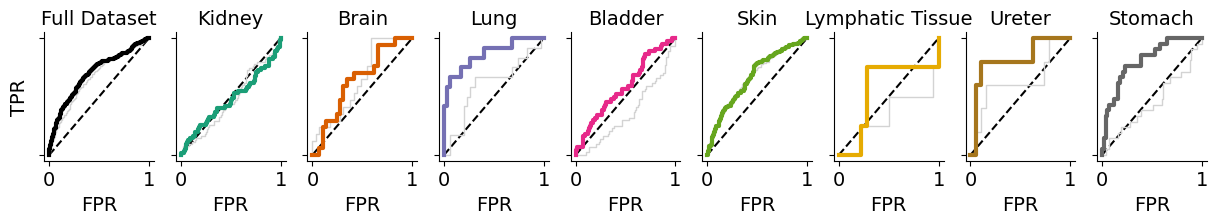

In [17]:
ftype = 'all_cliques'

fs = 14
N = len(roc_curves)
fig, axes = plt.subplots(1, N, figsize=(15, 15/N), sharey=True)

for i, cohort in enumerate(roc_curves.keys()):
    ax = axes[i]

    fpr_cliques = roc_curves[cohort]['all_cliques']['fpr']
    tpr_cliques = roc_curves[cohort]['all_cliques']['tpr']
    auc_cliques = roc_curves[cohort]['all_cliques']['auc']

    fpr_whole = roc_curves[cohort]['whole_transcriptome']['fpr']
    tpr_whole = roc_curves[cohort]['whole_transcriptome']['tpr']
    auc_whole = roc_curves[cohort]['whole_transcriptome']['auc']

    color = cohort_colors.get(cohort, 'black')
    title = cohort.replace('_', ' ').title()

    ax.set_title(f"{title}", fontsize=fs)
    ax.set_xlabel("FPR", fontsize=fs)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    if i == 0:
        ax.set_ylabel("TPR", fontsize=fs)
    else:
        ax.set_yticklabels([])  # Hide y-tick labels on other plots

    ax.plot([0, 1], [0, 1], color='k', linestyle="--", label="Random")
    ax.plot(fpr_cliques, tpr_cliques, label=f"{cohort} - {ftype} (AUC = {auc_cliques:.2f})", color=color, lw=3, zorder=10)
    ax.plot(fpr_whole, tpr_whole, label=f"{cohort} - Whole Transcriptome (AUC = {auc_whole:.2f})", color='lightgray', lw=1, zorder=5)

    ax.tick_params(axis='both', labelsize=fs)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.show()


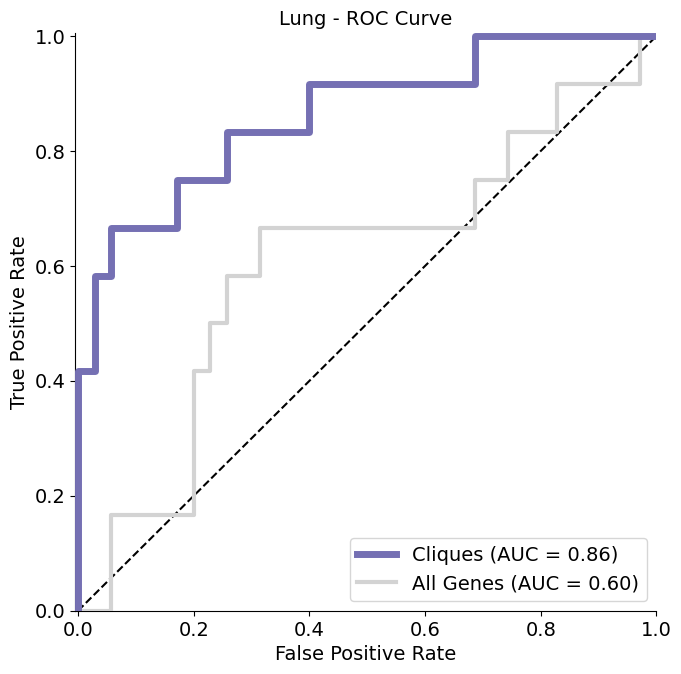

In [18]:
cohort = 'lung'

fig, ax = plt.subplots(1, 1, figsize=(7.5, 7.5))
fs = 14

fpr_cliques = roc_curves[cohort]['all_cliques']['fpr']
tpr_cliques = roc_curves[cohort]['all_cliques']['tpr']
auc_cliques = roc_curves[cohort]['all_cliques']['auc']

fpr_whole = roc_curves[cohort]['whole_transcriptome']['fpr']
tpr_whole = roc_curves[cohort]['whole_transcriptome']['tpr']
auc_whole = roc_curves[cohort]['whole_transcriptome']['auc']

color = cohort_colors.get(cohort, 'black')
title = cohort.replace('_', ' ').title()

ax.set_title(f"{title} - ROC Curve", fontsize=fs)

ax.set_xlabel("False Positive Rate", fontsize=fs)
ax.set_ylabel("True Positive Rate", fontsize=fs)

ax.plot([0, 1], [0, 1], color='k', linestyle="--", label="")
ax.plot(fpr_cliques, tpr_cliques, label=f"Cliques (AUC = {auc_cliques:.2f})", color=color, lw=5, zorder=10)
ax.plot(fpr_whole, tpr_whole, label=f"All Genes (AUC = {auc_whole:.2f})", color='lightgray', lw=3, zorder=5)
ax.set_xlim(-0.005, 1)
ax.set_ylim(0, 1.005)

plt.legend(fontsize=fs)

ax.tick_params(axis='both', labelsize=fs)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#plt.savefig('/home/lnemati/pathway_crosstalk/results/supplementary/lung_roc.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/supplementary/lung_roc.png', bbox_inches='tight', dpi=300)

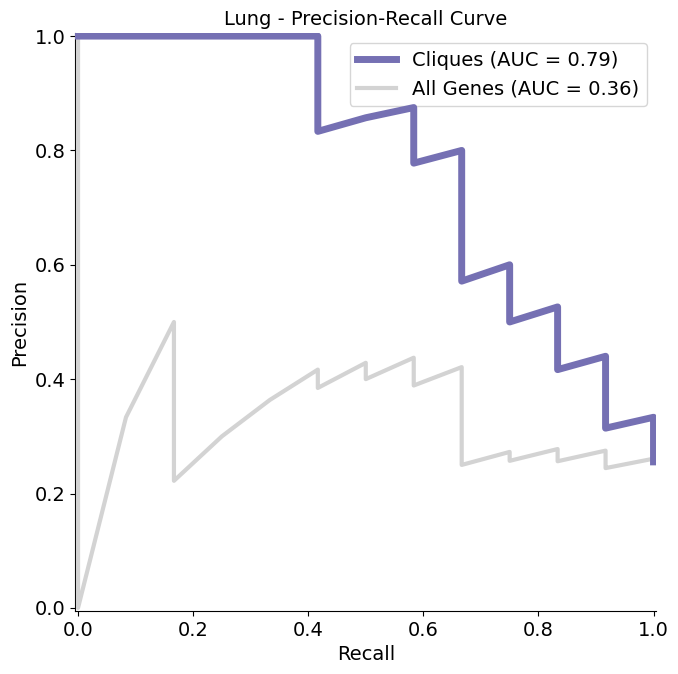

In [19]:
cohort = 'lung'

fig, ax = plt.subplots(1, 1, figsize=(7.5, 7.5))

# Extract PR data
precision_cliques = pr_curves[cohort]['all_cliques']['precision']
recall_cliques = pr_curves[cohort]['all_cliques']['recall']
auc_cliques = pr_curves[cohort]['all_cliques']['auprc']

precision_whole = pr_curves[cohort]['whole_transcriptome']['precision']
recall_whole = pr_curves[cohort]['whole_transcriptome']['recall']
auc_whole = pr_curves[cohort]['whole_transcriptome']['auprc']

# Plot setup
color = cohort_colors.get(cohort, 'black')
title = cohort.replace('_', ' ').title()

ax.set_title(f"{title} - Precision-Recall Curve", fontsize=fs)

ax.set_xlabel("Recall", fontsize=fs)
ax.set_ylabel("Precision", fontsize=fs)

# Plot PR curves
ax.plot(recall_cliques, precision_cliques, label=f"Cliques (AUC = {auc_cliques:.2f})", color=color, lw=5, zorder=10)
ax.plot(recall_whole, precision_whole, label=f"All Genes (AUC = {auc_whole:.2f})", color='lightgray', lw=3, zorder=5)

# Dashed line is optional for PR curves (not a 45-degree baseline)
ax.set_xlim(-0.005, 1.005)
ax.set_ylim(-0.005, 1.005)

plt.legend(fontsize=fs)

ax.tick_params(axis='both', labelsize=fs)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


#plt.savefig('/home/lnemati/pathway_crosstalk/results/supplementary/lung_prc.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/supplementary/lung_prc.png', bbox_inches='tight', dpi=300)

In [20]:
## Read the results
parentdir = '/home/lnemati/pathway_crosstalk/results/immunotherapy/individual_interactions_and_motifs'

dfs = []

for tissue in os.listdir(parentdir):
    #if tissue in ['full_dataset']: # add back lymph and ureter when they finish running
    #    continue
    path = os.path.join(parentdir, tissue, 'aggregated', 'aggregated.csv')
    tissuedf = pd.read_csv(os.path.join(path))
    tissuedf = tissuedf.rename(columns={'Unnamed: 0': 'interaction'})
    #tissuedf['motif'] = tissuedf['motif'].replace({'3_clique': 'cliques', '4_clique': 'cliques'})

    dfs.append(tissuedf)
        
crosstalkdf = pd.concat(dfs, ignore_index=True)

In [21]:
## Read the results
parentdir = '/home/lnemati/pathway_crosstalk/results/immunotherapy/individual_interactions_and_motifs'

dfs = []

for tissue in os.listdir(parentdir):
    #if tissue in ['full_dataset']: # add back lymph and ureter when they finish running
    #    continue
    path = os.path.join(parentdir, tissue, 'aggregated', 'aggregated.csv')
    tissuedf = pd.read_csv(os.path.join(path))
    tissuedf = tissuedf.rename(columns={'Unnamed: 0': 'interaction'})
    #tissuedf['motif'] = tissuedf['motif'].replace({'3_clique': 'cliques', '4_clique': 'cliques'})

    dfs.append(tissuedf)
        
crosstalkdf = pd.concat(dfs, ignore_index=True)
#crosstalkdf = crosstalkdf.dropna()

crosstalkdf = crosstalkdf.sort_values(by='auroc')[::-1]

crosstalkdf = crosstalkdf.query('motif != "random_pairs"')
#crosstalkdf = crosstalkdf.query('tissue != "full_dataset"')

better = crosstalkdf.query('auroc > auroc1 and auroc > auroc2')
better = better.query('auprc > auprc1 and auprc > auprc2')

In [22]:
df = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/motifs_permutations.csv')
motifs = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/counts.csv', index_col='motif')
motifs = motifs['number'] 

df3 = df[[col for col in df.columns if col.startswith('3')]]
df4 = df[[col for col in df.columns if col.startswith('4')]]
motifs3 = motifs.loc[[idx for idx in motifs.index if idx.startswith('3')]]
motifs4 = motifs.loc[[idx for idx in motifs.index if idx.startswith('4')]]

motifs3 = motifs3 / motifs3.sum()
motifs4 = motifs4 / motifs4.sum()
df3 = (df3.T / df3.sum(1)).T
df4 = (df4.T / df4.sum(1)).T

df = df3.join(df4)
motifs = pd.concat([motifs3, motifs4])

means = df.mean()
stds = df.std()

motifs_z = ((motifs - means) / stds).sort_values()
motifs_z.name = 'z'

/var/tmp/pbs.436024.pbs01/ipykernel_292477/3799571848.py:45: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


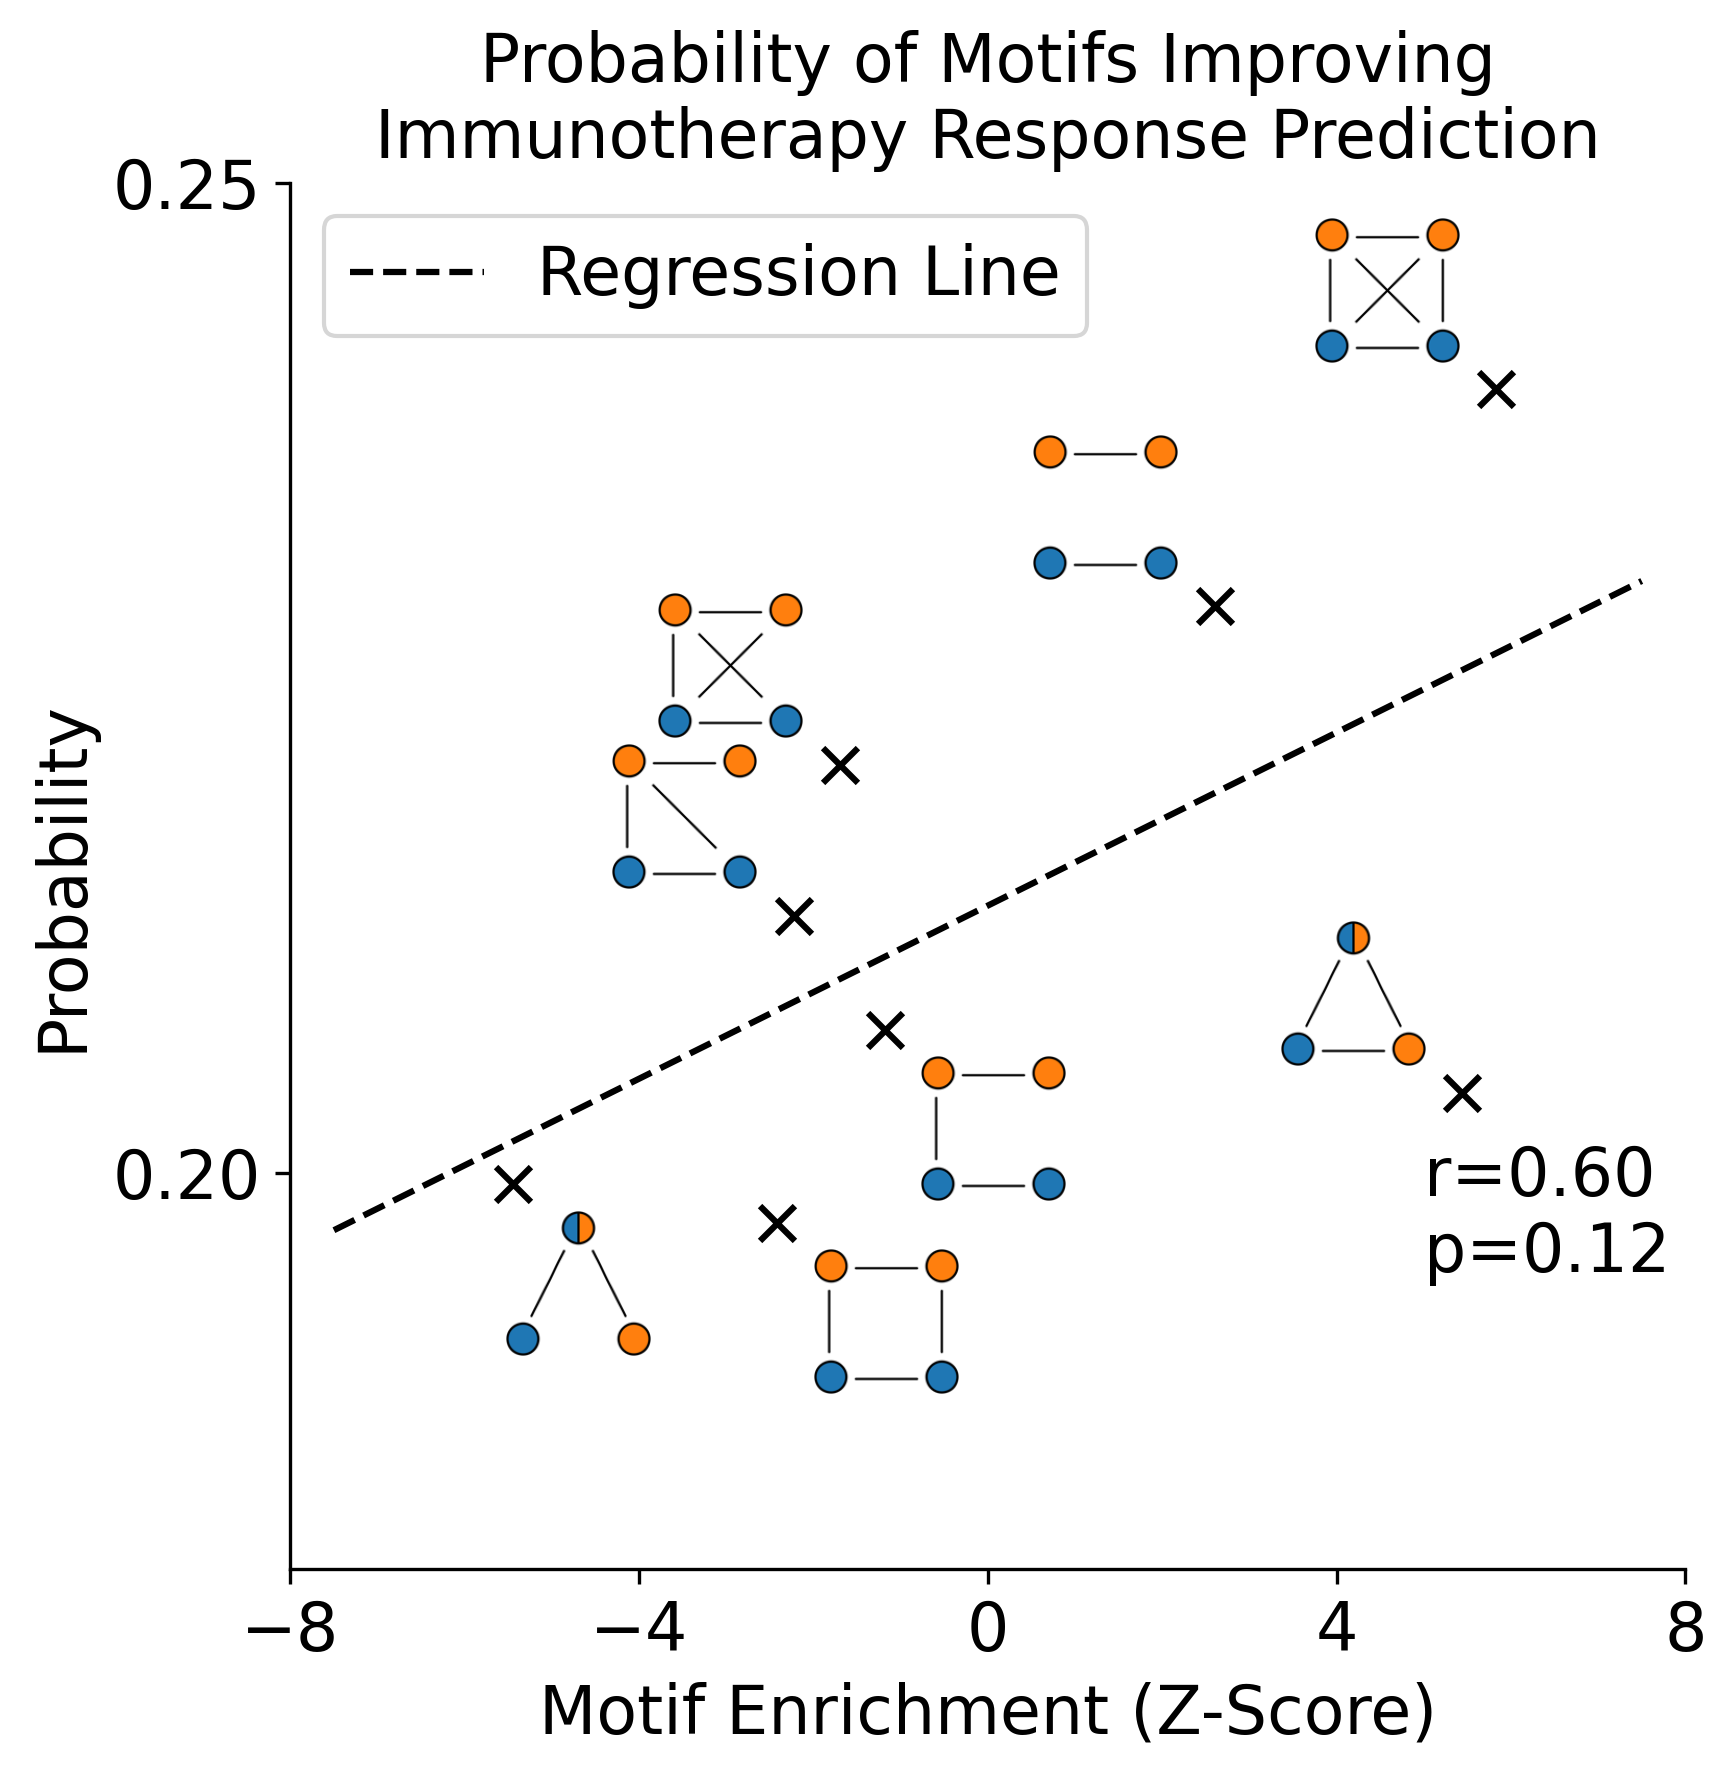

In [23]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import image as mpimg
import os
from PIL import Image

# Constants
dpi = 300
img_dir = '/home/lnemati/pathway_crosstalk/data/motifs_icons/'  # Update this path
image_scaling_factor = 0.25  # Adjust this factor to scale image size (smaller = more zoomed out)
x_offset = -1.25
y_offset = 0.005

fs = 16

# Filter data
#all_counts = crosstalkdf.query('tissue != "full_dataset"').motif.value_counts().sort_values(ascending=False)

probs = (better.query('tissue != "full_dataset"').motif.value_counts() / crosstalkdf.query('tissue != "full_dataset"').motif.value_counts()).sort_values()
#probs = (better.motif.value_counts() / crosstalkdf.motif.value_counts()).sort_values()
probs = probs.loc[motifs_z.index]

data = pd.DataFrame()
data['z'] = motifs_z
data['prob'] = probs

# Calculate Pearson correlation
r_value, p_value = pearsonr(probs, motifs_z)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=dpi)

# Plot the scatter points
#ax.scatter(
#    data['z'], 
#    data['prob'], 
#    color=lightgray, 
#    marker='s', 
#    edgecolors='black',  # Black edge color
#    s=70,
#    linewidths=1.5  # Thickness of the edge
#)
ax.scatter(
    data['z'], 
    data['prob'], 
    #color='black', 
    color='black', 
    marker='x', 
    edgecolors='black',  # Black edge color
    s=70,
    linewidths=1.5  # Thickness of the edge
)

# Add Pearson correlation to plot
ax.text(5, 0.195, 'r={:.2f}\np={:.2f}'.format(r_value, p_value), fontsize=fs)

# Set limits and ticks
ax.set_xlim(-8, 8)
ax.set_ylim(0.18, 0.25)
xticks = [-8, -4, 0, 4, 8]
yticks = [0.2, 0.25]
ax.set_xticks(xticks)
ax.set_yticks(yticks)

# Hide top and right spines
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(labelsize=fs)

# Add title and labels
ax.set_title('Probability of Motifs Improving\nImmunotherapy Response Prediction', fontsize=fs)
ax.set_xlabel('Motif Enrichment (Z-Score)', fontsize=fs)
ax.set_ylabel('Probability', fontsize=fs)

# Make the background of the plot transparent so the images can show up
ax.patch.set_alpha(0)

# Get the regression line parameters (slope and intercept)
slope, intercept = np.polyfit(data['z'], data['prob'], 1)

# Extend the regression line beyond the data range
x_extended = np.linspace(ax.get_xlim()[0] + 0.5, ax.get_xlim()[1] - 0.5, 100)
y_extended = slope * x_extended + intercept
ax.plot(x_extended, y_extended, linestyle='--', color='k', linewidth=1.5, label='Regression Line', zorder=-10)

# Dictionary to define manual positions for each motif
motif_positions = {
    '3_path': (data['z']['3_path']+2, data['prob']['3_path']-0.01),
    '4_cycle': (data['z']['4_cycle']+2.5, data['prob']['4_cycle']-0.01),
    '4_triangle_extra': (data['z']['4_triangle_extra'], data['prob']['4_triangle_extra']),
    '4_one_missing': (data['z']['4_one_missing'], data['prob']['4_one_missing']),
    '4_path': (data['z']['4_path']+2.5, data['prob']['4_path']-0.01),
    '4_no_crosstalk': (data['z']['4_no_crosstalk'], data['prob']['4_no_crosstalk']),
    '3_clique': (data['z']['3_clique'], data['prob']['3_clique']),
    '4_clique': (data['z']['4_clique'], data['prob']['4_clique']),
}

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

for motif, (x_pos, y_pos) in motif_positions.items():
    img_path = os.path.join(img_dir, f"{motif}.png")
    if os.path.exists(img_path):
        im = Image.open(img_path)
        im = im.resize((int(im.width * image_scaling_factor), int(im.height * image_scaling_factor)))
        imagebox = OffsetImage(im, zoom=image_scaling_factor, resample=True)
        ab = AnnotationBbox(imagebox, (x_pos + x_offset, y_pos + y_offset), frameon=False)
        ax.add_artist(ab)


# Hide legend, as it may conflict with the images
#plt.legend([], [], frameon=False)
plt.legend(fontsize=fs, loc='upper left')

#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/immunotherapy/motifs_z_prob.pdf', bbox_inches='tight', dpi=dpi)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/immunotherapy/motifs_z_prob.png', bbox_inches='tight', dpi=dpi)

# Show the plot
plt.show()


/var/tmp/pbs.436024.pbs01/ipykernel_292477/1295938473.py:31: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(data['z'], data['prob'], color='black', marker='x', edgecolors='black', s=70, linewidths=1.5)


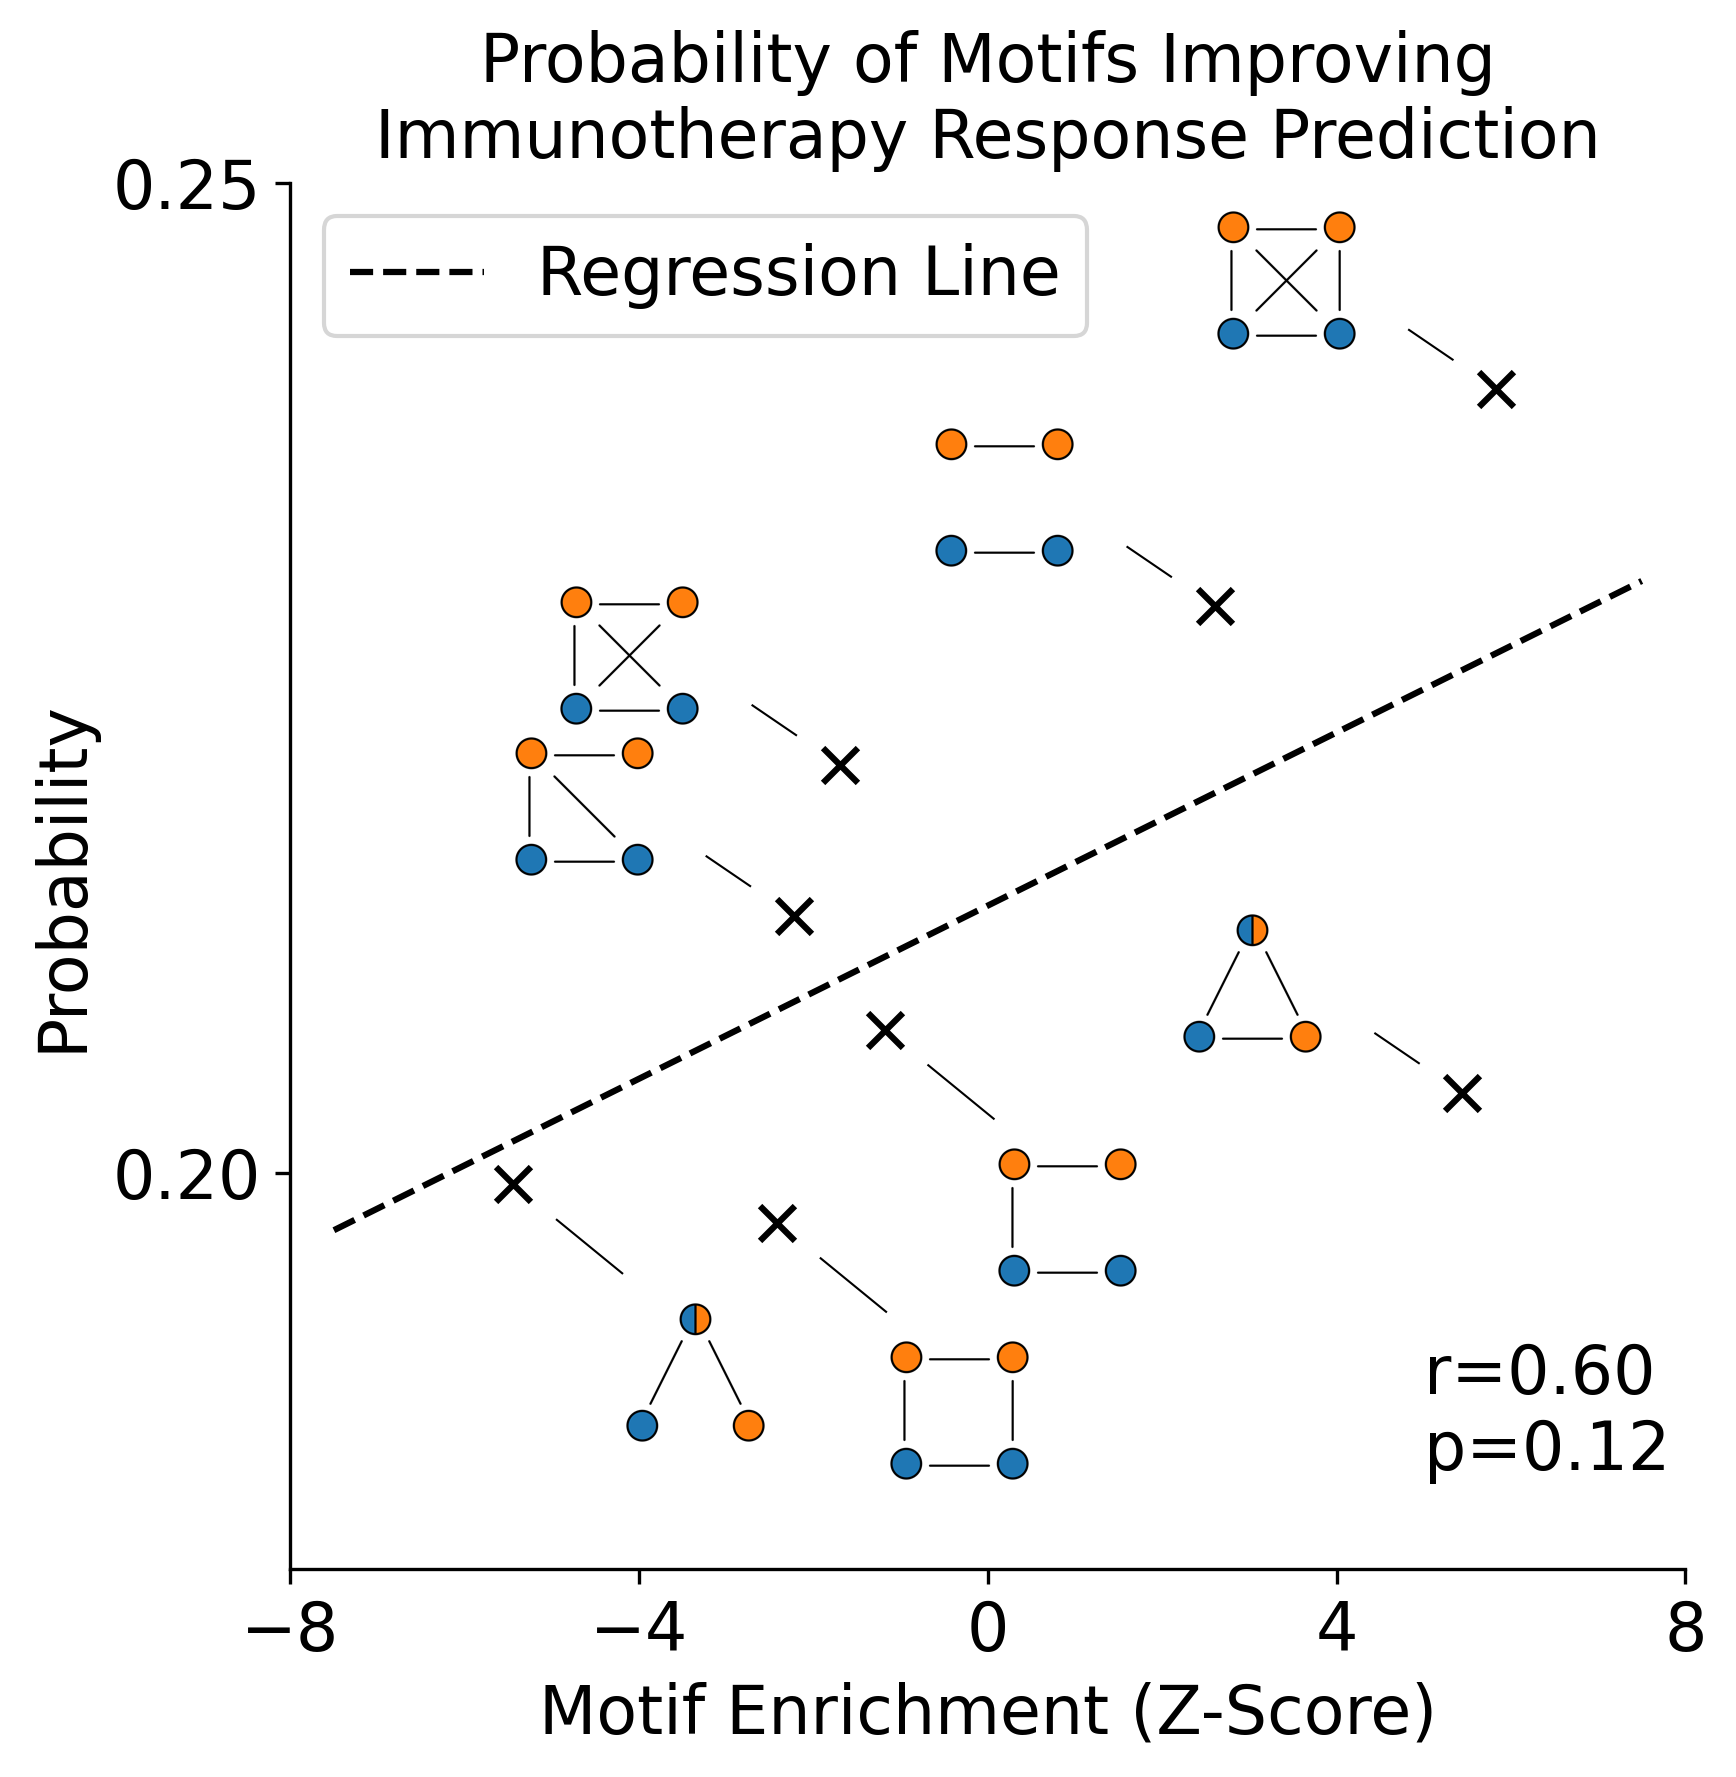

In [24]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from PIL import Image
import pandas as pd

# Constants
dpi = 300
img_dir = '/home/lnemati/pathway_crosstalk/data/motifs_icons/'
image_scaling_factor = 0.25
x_offset = 30  # in pixels
y_offset = 0.  # in data coordinates (converted later)
fs = 16

# Filter and prepare data
probs = (better.query('tissue != "full_dataset"').motif.value_counts() / 
         crosstalkdf.query('tissue != "full_dataset"').motif.value_counts()).sort_values()
probs = probs.loc[motifs_z.index]

data = pd.DataFrame({'z': motifs_z, 'prob': probs})

# Calculate Pearson correlation
r_value, p_value = pearsonr(probs, motifs_z)

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=dpi)

# Plot data points
ax.scatter(data['z'], data['prob'], color='black', marker='x', edgecolors='black', s=70, linewidths=1.5)

# Annotate with correlation
ax.text(5, 0.185, 'r={:.2f}\np={:.2f}'.format(r_value, p_value), fontsize=fs)

# Axes formatting
ax.set_xlim(-8, 8)
ax.set_ylim(0.18, 0.25)
ax.set_xticks([-8, -4, 0, 4, 8])
ax.set_yticks([0.2, 0.25])
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(labelsize=fs)
ax.set_title('Probability of Motifs Improving\nImmunotherapy Response Prediction', fontsize=fs)
ax.set_xlabel('Motif Enrichment (Z-Score)', fontsize=fs)
ax.set_ylabel('Probability', fontsize=fs)
ax.patch.set_alpha(0)  # Transparent background

# Regression line
slope, intercept = np.polyfit(data['z'], data['prob'], 1)
x_ext = np.linspace(ax.get_xlim()[0] + 0.5, ax.get_xlim()[1] - 0.5, 100)
y_ext = slope * x_ext + intercept
ax.plot(x_ext, y_ext, linestyle='--', color='k', linewidth=1.5, label='Regression Line', zorder=-10)

# Manual image positions
motif_positions = {
    '3_path': (data['z']['3_path']+2.5, data['prob']['3_path']-0.009),
    '4_cycle': (data['z']['4_cycle']+2.5, data['prob']['4_cycle']-0.009),
    '4_triangle_extra': (data['z']['4_triangle_extra']-2, data['prob']['4_triangle_extra']+0.006),
    '4_one_missing': (data['z']['4_one_missing']-2, data['prob']['4_one_missing']+0.006),
    '4_path': (data['z']['4_path']+2.5, data['prob']['4_path']-0.009),
    '4_no_crosstalk': (data['z']['4_no_crosstalk']-2, data['prob']['4_no_crosstalk']+0.006),
    '3_clique': (data['z']['3_clique']-2, data['prob']['3_clique']+0.006),
    '4_clique': (data['z']['4_clique']-2, data['prob']['4_clique']+0.006),
}

# Draw icons and connecting lines
for motif, (x_pos, y_pos) in motif_positions.items():
    img_path = os.path.join(img_dir, f"{motif}.png")
    if os.path.exists(img_path):
        im = Image.open(img_path)
        width, height = im.size
        im_resized = im.resize((int(width * image_scaling_factor), int(height * image_scaling_factor)))
        im_resized_np = np.array(im_resized)

        # Convert data coordinates to pixels
        pixel_pos = ax.transData.transform((x_pos, y_pos + y_offset))

        # Place image
        fig.figimage(
            im_resized_np,
            pixel_pos[0] - im_resized_np.shape[1] / 2 + x_offset,
            pixel_pos[1] - im_resized_np.shape[0] / 2,
            origin='upper'
        )

        # Draw line from marker to image
        line_frac = 0.5
        marker_trim = 0.5  # in data units

        # Get data position of marker and image
        x0, y0 = motifs_z.loc[motif], probs.loc[motif]
        x1, y1 = ax.transData.inverted().transform(pixel_pos)

        dx = x1 - x0
        dy = y1 - y0
        line_length = np.hypot(dx, dy)

        dxn, dyn = dx / line_length, dy / line_length
        x_start = x0 + dxn * marker_trim
        y_start = y0 + dyn * marker_trim
        x_end = x1 - dxn * (line_frac * line_length)
        y_end = y1 - dyn * (line_frac * line_length)

        ax.plot([x_start, x_end], [y_start, y_end], color='k', linewidth=0.5, zorder=-5)

# Optional: legend, save, show
plt.legend(fontsize=fs, loc='upper left')

#plt.savefig('/home/lnemati/pathway_crosstalk/results/supplementary/motifs_z_prob.pdf', bbox_inches='tight', dpi=dpi)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/supplementary/motifs_z_prob.png', bbox_inches='tight', dpi=dpi)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/immunotherapy/motifs_z_prob.pdf', bbox_inches='tight', dpi=dpi)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/immunotherapy/motifs_z_prob.png', bbox_inches='tight', dpi=dpi)

plt.show()


In [25]:
## Read the results
parentdir = '/home/lnemati/pathway_crosstalk/results/immunotherapy/individual_interactions_and_motifs'

dfs = []

for tissue in os.listdir(parentdir):
    #if tissue in ['full_dataset']: # add back lymph and ureter when they finish running
    #    continue
    path = os.path.join(parentdir, tissue, 'aggregated', 'aggregated.csv')
    tissuedf = pd.read_csv(os.path.join(path))
    tissuedf = tissuedf.rename(columns={'Unnamed: 0': 'interaction'})
    #tissuedf['motif'] = tissuedf['motif'].replace({'3_clique': 'cliques', '4_clique': 'cliques'})

    dfs.append(tissuedf)
        
crosstalkdf = pd.concat(dfs, ignore_index=True)
crosstalkdf = crosstalkdf.dropna()

crosstalkdf = crosstalkdf.sort_values(by='auroc')[::-1]

#crosstalkdf = crosstalkdf.query('motif != "random_pairs"')
crosstalkdf = crosstalkdf.query('tissue != "full_dataset"')

better = crosstalkdf.query('auroc > auroc1 and auroc > auroc2')
better = better.query('auprc > auprc1 and auprc > auprc2')

In [26]:
# Assuming df is your dataframe
df_mean = crosstalkdf.groupby("interaction")[["auroc", "auroc_diff", "auprc", "auprc_diff"]].median().reset_index()
df_mean = df_mean.sort_values(by='auroc')[::-1]
df_mean.columns = ["interaction", "mean_auroc", "mean_auroc_diff", "mean_auprc", "mean_auprc_diff"]
# Create a mapping from interaction to motif
interaction_to_motif = crosstalkdf.drop_duplicates("interaction")[["interaction", "motif"]]

# Merge the motif info back to df_mean
df_mean = df_mean.merge(interaction_to_motif, on="interaction", how="left")

df_mean = df_mean.sort_values(by='mean_auroc')[::-1]
df_mean

#df_mean.to_csv('/home/lnemati/pathway_crosstalk/results/immunotherapy/aggregated/cliques_medians.csv')

,interaction,mean_auroc,mean_auroc_diff,mean_auprc,mean_auprc_diff,motif
0,HLA-F+KIR3DS1&GDF15+TGFBR2,0.819444,-0.010526,0.415476,-0.024738,random_pairs
1,CD4+HLA-DQB1&ACKR1+CCL5,0.736842,0.009190,0.428187,0.039016,4_clique
2,B4GALT3+P2RY14&CCL3L1+ACKR2,0.736111,0.000000,0.494298,0.000000,random_pairs
3,ACKR1+CXCL13&ACKR1+CCL5,0.732665,-0.009091,0.427959,-0.005230,3_clique
4,ACKR1+CXCL9&CD69+KLRB1,0.730828,-0.002041,0.452433,0.009255,4_clique
...,...,...,...,...,...,...
14701,WNT10A+FZD8_LRP5&WNT3+FZD1_LRP5,0.379017,-0.041249,0.211910,-0.023634,random_pairs
14702,ITGA2_ITGB1+LAMA5&DAG1+LAMA5,0.378565,-0.094448,0.228983,-0.037806,3_clique
14703,TGM2+ADGRG1&FGF5+FGFR2,0.366370,-0.102196,0.239037,-0.038850,random_pairs
14704,DDC+HTR7&GAD2_SLC6A13+GABRA1_GABRB2,0.358831,-0.087774,0.260632,-0.053538,random_pairs


In [27]:
crosstalkdf['motif'] = crosstalkdf.motif.replace({
    '3_clique': 'Cliques',
    '4_clique': 'Cliques',
    'random_pairs': 'Random Pairs',
    '4_cycle': 'Other Motifs',
    '4_path': 'Other Motifs',
    '4_triangle_extra': 'Other Motifs',
    '4_no_crosstalk': 'Other Motifs',
    '4_one_missing': 'Other Motifs',
    '3_path': 'Other Motifs',
})

df_mean['motif'] = df_mean.motif.replace({
    '3_clique': 'Cliques',
    '4_clique': 'Cliques',
    'random_pairs': 'Random Pairs',
    '4_cycle': 'Other Motifs',
    '4_path': 'Other Motifs',
    '4_triangle_extra': 'Other Motifs',
    '4_no_crosstalk': 'Other Motifs',
    '4_one_missing': 'Other Motifs',
    '3_path': 'Other Motifs',
})

/var/tmp/pbs.436024.pbs01/ipykernel_292477/1892921777.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_mean, y='mean_auroc', x='motif', order=sorted_motifs, palette=palette_sorted, ax=ax1, inner='quart', cut=0)
/var/tmp/pbs.436024.pbs01/ipykernel_292477/1892921777.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_mean, y='mean_auprc', x='motif', order=sorted_motifs, palette=palette_sorted, ax=ax2, inner='quart', cut=0)
/var/tmp/pbs.436024.pbs01/ipykernel_292477/1892921777.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().title().replace('_

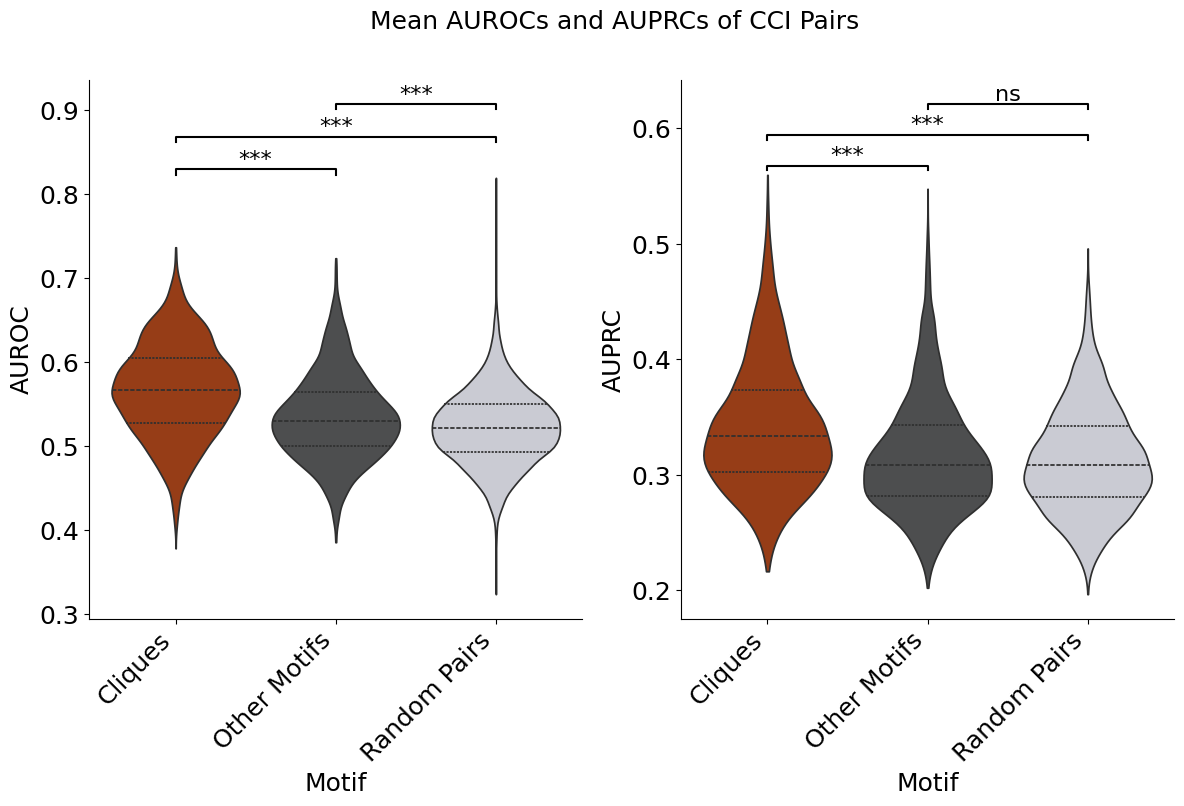

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import itertools
import numpy as np

fs = 18

palette = {'Random Pairs': lightgray, 'Other Motifs': graycolor, 'Cliques': tcolor}

# Sort motif categories by median AUROC
median_auroc = df_mean.groupby('motif')['mean_auroc'].median().sort_values(ascending=False)
sorted_motifs = median_auroc.index.tolist()

# Reorder palette to match sorted motifs
palette_sorted = {motif: palette[motif.title().replace('_', ' ')] if motif.title().replace('_', ' ') in palette else 'gray' for motif in sorted_motifs}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Plot violinplots with sorted order
sns.violinplot(data=df_mean, y='mean_auroc', x='motif', order=sorted_motifs, palette=palette_sorted, ax=ax1, inner='quart', cut=0)
sns.violinplot(data=df_mean, y='mean_auprc', x='motif', order=sorted_motifs, palette=palette_sorted, ax=ax2, inner='quart', cut=0)

# Prepare all pairs for comparison
pairs = list(itertools.combinations(sorted_motifs, 2))

# Function to get p-value for pair and metric
def get_pval(group1, group2, metric):
    data1 = df_mean.query(f'motif == "{group1}"')[metric].dropna()
    data2 = df_mean.query(f'motif == "{group2}"')[metric].dropna()
    return mannwhitneyu(data1, data2).pvalue

# Significance label function
def get_sig_label(pval):
    if pval > 0.05:
        return "ns"
    elif pval > 0.01:
        return "*"
    elif pval > 0.001:
        return "**"
    else:
        return "***"
    return

# Function to add significance bars for all pairs
def add_all_significance_bars(ax, metric, y_start=0.05, y_step=0.05, height=0.008):
    ylim = ax.get_ylim()
    y_max = 0.92*ylim[1]
    
    for i, (g1, g2) in enumerate(pairs):
        pval = get_pval(g1, g2, metric)
        x1, x2 = sorted_motifs.index(g1), sorted_motifs.index(g2)
        y = y_max + y_start * y_max + i * y_step * y_max
        
        # Draw bar
        ax.plot([x1, x1, x2, x2], [y, y + height * y_max, y + height * y_max, y], lw=1.5, c='black')
        ax.text((x1 + x2) / 2, y + height * y_max, get_sig_label(pval), ha='center', va='bottom', fontsize=fs*0.9)

# Add significance bars to each plot
add_all_significance_bars(ax1, 'mean_auroc', y_start=0.06)
add_all_significance_bars(ax2, 'mean_auprc', y_start=0.06)

ax1.set_ylabel('AUROC')
ax2.set_ylabel('AUPRC')

# Formatting axes
for ax in (ax1, ax2):
    ax.tick_params(axis='both', labelsize=fs)
    ax.set_xlabel(ax.get_xlabel().title(), fontsize=fs)
    ax.set_ylabel(ax.get_ylabel().upper(), fontsize=fs)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticklabels([label.get_text().title().replace('_', ' ') for label in ax.get_xticklabels()], rotation=45, ha='right')

fig.suptitle('Mean AUROCs and AUPRCs of CCI Pairs', fontsize=fs)

#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/immunotherapy/individual_pairs_auroc_auprc_violinplot.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/immunotherapy/individual_pairs_auroc_auprc_violinplot.png', bbox_inches='tight', dpi=300)    

plt.show()


In [29]:
pairs
for i, (g1, g2) in enumerate(pairs):
    print(g1, g2)
    pval = get_pval(g1, g2, 'mean_auroc')
    print(pval)

Cliques Other Motifs
1.626873282381062e-183
Cliques Random Pairs
0.0
Other Motifs Random Pairs
7.811091408865756e-30


In [30]:
pairs
for i, (g1, g2) in enumerate(pairs):
    print(g1, g2)
    pval = get_pval(g1, g2, 'mean_auprc')
    print(pval)

Cliques Other Motifs
1.0301667464730957e-118
Cliques Random Pairs
7.028479856842942e-131
Other Motifs Random Pairs
0.10697604825901569


In [31]:
better = crosstalkdf.query('auroc > auroc1 and auroc > auroc2')
better = better.query('auprc > auprc1 and auprc > auprc2')

In [32]:
better

,interaction,auroc,auroc1,auroc2,auprc,auprc1,auprc2,auroc_diff,auprc_diff,motif,tissue
105512,SOSTDC1+LRP6&INHBC+ACVR1B_ACVR2B,1.000000,0.978947,0.694737,1.000000,0.942857,0.361905,0.021053,0.057143,Random Pairs,ureter
105495,SOSTDC1+LRP6&CCL5+ACKR2,1.000000,0.978947,0.831579,1.000000,0.942857,0.457778,0.021053,0.057143,Random Pairs,ureter
103591,ENTPD1+ADORA3&GAD2_SLC6A13+GABRA1_GABRB2,1.000000,0.884211,0.831579,1.000000,0.564444,0.597222,0.115789,0.402778,Random Pairs,ureter
105497,WNT16+FZD10_LRP5&GAD2_SLC6A12+GABBR1,1.000000,0.473684,0.978947,1.000000,0.251985,0.942857,0.021053,0.057143,Random Pairs,ureter
103305,CXCL10+CXCR3&MRC1+PTPRC,1.000000,0.673684,0.757895,1.000000,0.435948,0.508824,0.242105,0.491176,Cliques,ureter
...,...,...,...,...,...,...,...,...,...,...,...
91306,CD44+SIGLEC15&HLA-G+LILRB1,0.236111,0.222222,0.180556,0.145644,0.143640,0.137202,0.013889,0.002004,Other Motifs,lymphatic_tissue
46339,INHA_INHBA+ACVR1C_ACVR2A&MDK+ITGA6_ITGB1,0.230952,0.169048,0.219048,0.179836,0.168484,0.176271,0.011905,0.003565,Random Pairs,lung
91275,PGF+FLT1&SEMA4D+CD72,0.208333,0.097222,0.194444,0.142038,0.127127,0.139531,0.013889,0.002507,Random Pairs,lymphatic_tissue
105283,COL22A1+ITGA1_ITGB1&COL6A3+ITGA1_ITGB1,0.178947,0.157895,0.147368,0.152815,0.148960,0.150021,0.021053,0.002794,Cliques,ureter


/var/tmp/pbs.436024.pbs01/ipykernel_292477/1550507398.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels)


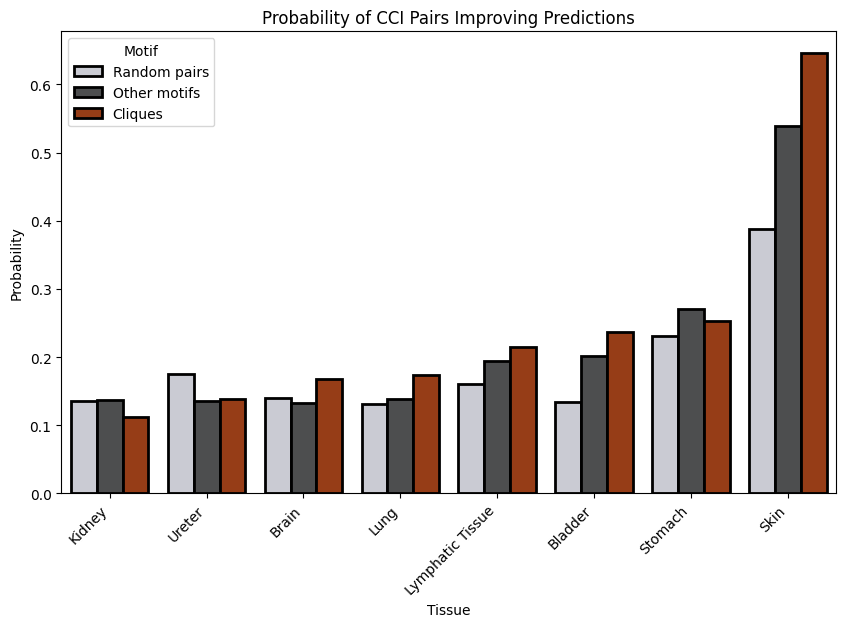

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compute probabilities separately for each tissue
probs_by_tissue = []
for tissue, better_group in better.groupby('tissue'):
    crosstalk_group = crosstalkdf[crosstalkdf['tissue'] == tissue]
    
    probs = (better_group.dropna().motif.value_counts() / crosstalk_group.dropna().motif.value_counts()).dropna()
    
    df = probs.reset_index()
    df.columns = ['motif', 'prob']
    df['tissue'] = tissue
    probs_by_tissue.append(df)

# Combine results
plot_df = pd.concat(probs_by_tissue)

# Sort tissues by "cliques" probability (ascending order)
tissue_order = (
    plot_df[plot_df['motif'] == 'Cliques']
    .sort_values(by='prob', ascending=True)['tissue']
    .tolist()
)

# Set tissue as categorical with the specified order
plot_df['tissue'] = pd.Categorical(plot_df['tissue'], categories=tissue_order, ordered=True)

# Plot barplot
plt.figure(figsize=(10, 6))
#palette={'cliques': orangecolor, 'random_pairs':lightgray}
#palette={'cliques': tcolor, 'random_pairs': ncolor}
palette = {'Random Pairs': lightgray, 'Other Motifs': graycolor, 'Cliques': tcolor}

hue_order=['Random Pairs', 'Other Motifs', 'Cliques']
sns.barplot(data=plot_df, x='tissue', y='prob', hue='motif', palette=palette, linewidth=2, edgecolor='k', hue_order=hue_order)

# Improve x-axis readability
plt.xticks(rotation=45, ha='right')

# Capitalize x labels and replace underscores with spaces
new_labels = [label.get_text().title().replace('_', ' ') for label in plt.gca().get_xticklabels()]
plt.gca().set_xticklabels(new_labels)

# Capitalize legend labels and replace underscores with spaces
handles, labels = plt.gca().get_legend_handles_labels()
new_labels_legend = [label.capitalize().replace('_', ' ') for label in labels]
plt.legend(handles=handles, labels=new_labels_legend, title='Motif')

plt.xlabel('Tissue')
plt.ylabel('Probability')
plt.title('Probability of CCI Pairs Improving Predictions')

#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/immunotherapy/individual_pairs_tissues_prob_better.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/immunotherapy/individual_pairs_tissues_prob_better.png', bbox_inches='tight', dpi=300)    

plt.show()

# Heatmap Top by Mean Across Tissues

In [34]:
## Read the results
parentdir = '/home/lnemati/pathway_crosstalk/results/immunotherapy/individual_interactions_and_motifs'

dfs = []

for tissue in os.listdir(parentdir):
    #if tissue in ['full_dataset']: # add back lymph and ureter when they finish running
    #    continue
    path = os.path.join(parentdir, tissue, 'aggregated', 'aggregated.csv')
    tissuedf = pd.read_csv(os.path.join(path))
    tissuedf = tissuedf.rename(columns={'Unnamed: 0': 'interaction'})
    #tissuedf['motif'] = tissuedf['motif'].replace({'3_clique': 'cliques', '4_clique': 'cliques'})

    dfs.append(tissuedf)
        
crosstalkdf = pd.concat(dfs, ignore_index=True)
#crosstalkdf = crosstalkdf.dropna()

crosstalkdf = crosstalkdf.sort_values(by='auroc')[::-1]

crosstalkdf = crosstalkdf.query('motif in ["3_clique", "4_clique"]')
#crosstalkdf = crosstalkdf.query('tissue != "full_dataset"')

better = crosstalkdf.query('auroc > auroc1 and auroc > auroc2')
better = better.query('auprc > auprc1 and auprc > auprc2')

crosstalkdf['orig_name'] = crosstalkdf['interaction']
better['orig_name'] = better['interaction']

crosstalkdf['interaction'] = crosstalkdf.interaction.str.replace('_', ' - ').str.replace('+', ' - ').str.replace('&', ' & ')
better['interaction'] = better.interaction.str.replace('_', ' - ').str.replace('+', ' - ').str.replace('&', ' & ')

# Get top interactions by mean auroc
crosstalkdf['auroc_filled'] = crosstalkdf['auroc'].copy()
crosstalkdf['auroc_filled'] = crosstalkdf.groupby('tissue')['auroc_filled'].transform(lambda x: x.fillna(x.mean()))

interactions_show = crosstalkdf.groupby('interaction')['auroc_filled'].mean().sort_values()[::-1].head(50).index.tolist()

# Get top interactions in each tissue
#interactions_show = better.sort_values(by='auroc')[::-1].groupby('tissue').head(5).interaction.tolist()

# Filter crosstalkdf for these top interactions only
# Prepare pivot
aurocs_df = crosstalkdf.pivot_table(
    index='interaction',
    columns='tissue',
    values='auroc',
    aggfunc='mean'
)

aurocs_df['interaction'] = aurocs_df.index

aurocs_df = aurocs_df[aurocs_df['interaction'].isin(interactions_show)]
#aurocs_df['interaction'] = aurocs_df.interaction.str.replace('_', ' - ').str.replace('+', ' - ').str.replace('&', ' & ')

import re

# Split interactions into individual genes for each side
aurocs_df['interaction1'] = aurocs_df.interaction.apply(lambda x: re.split('&', x)[0].strip().split(' - '))
aurocs_df['interaction2'] = aurocs_df.interaction.apply(lambda x: re.split('&', x)[1].strip().split(' - '))

# Load hallmark gene sets
def read_gmt(file_path):
    gene_sets = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                gene_sets[parts[0]] = set(parts[2:])
    return gene_sets

hallmarks_path = '/home/lnemati/resources/msigdb_hallmarks/h.all.v2024.1.Hs.symbols.gmt'
hallmarks = read_gmt(hallmarks_path)

# Generate cleaned hallmark labels
labels = [label.replace('HALLMARK_', '').replace('_', ' ').title() for label in hallmarks.keys()]

replace = {
    'Myc': 'MYC',
    'Kras': 'KRAS',
    'Il2': 'IL2',
    'Stat5': 'STAT5',
    'Il6': 'IL6',
    'Jak': 'JAK',
    'Stat3': 'STAT3',
    'P53': 'P53',
    'Tnfa': 'TNFα',
    'Nfkb': 'NF-κB',
    'Mtorc1': 'mTORC1',
    'Mtorc': 'mTORC',
    'Mtor': 'mTOR',
    ' Dn': ' Down',
    'Pi3K': 'PI3K',
    ' Akt': ' AKT',
    'Epithelial Mesenchymal Transition': 'E-M Transition'
}

for str1, str2 in replace.items():
    labels = [label.replace(str1, str2) for label in labels]

hallmark_name_map = dict(zip(hallmarks.keys(), labels))

# Function to find matching hallmark sets for a given gene list
def find_matching_hallmarks(gene_list, hallmark_sets):
    return [name for name, genes in hallmark_sets.items() if set(gene_list) & genes]

# Get hallmarks for each side of the interaction
aurocs_df['hallmarks1'] = aurocs_df['interaction1'].apply(lambda genes: find_matching_hallmarks(genes, hallmarks))
aurocs_df['hallmarks2'] = aurocs_df['interaction2'].apply(lambda genes: find_matching_hallmarks(genes, hallmarks))

# Convert to readable labels using the name map
aurocs_df['hallmarks1'] = aurocs_df['hallmarks1'].apply(lambda hlist: [hallmark_name_map[h] for h in hlist])
aurocs_df['hallmarks2'] = aurocs_df['hallmarks2'].apply(lambda hlist: [hallmark_name_map[h] for h in hlist])

crosstalkdf_with_orig_name = crosstalkdf.copy()

In [35]:
import numpy as np

# Define subset of hallmarks you want to consider (for example, top N or all unique found)
# For demonstration, use all unique hallmarks found across both sides:
all_hallmarks = sorted(set(sum(aurocs_df['hallmarks1'], [])) | set(sum(aurocs_df['hallmarks2'], [])))

# Initialize matrix: rows = interactions, columns = hallmarks
heatmap_matrix = np.zeros((len(aurocs_df), len(all_hallmarks)), dtype=int)

# Fill matrix with presence codes
for i, row in enumerate(aurocs_df.itertuples(index=False)):
    hallmarks_1 = set(row.hallmarks1)
    hallmarks_2 = set(row.hallmarks2)
    for j, hallmark in enumerate(all_hallmarks):
        in_1 = hallmark in hallmarks_1
        in_2 = hallmark in hallmarks_2
        heatmap_matrix[i, j] = 1 * in_1 + 2 * in_2  # 0, 1, 2, or 3

heatmap_df = pd.DataFrame(heatmap_matrix, index=aurocs_df.interaction, columns=all_hallmarks)    
heatmap_df = heatmap_df[::-1] # Invert to match order of the plot

# Values:
# 0 = not present
# 1 = interaction1
# 2 = interaction2
# 3 = both interactions

aurocs_df = aurocs_df[['bladder', 'brain', 'full_dataset', 'kidney', 'lung', 'lymphatic_tissue', 'skin', 'stomach', 'ureter']]
cols = [col.title().replace('_', ' ') for col in aurocs_df.columns]
aurocs_df.columns = cols

In [36]:
## Read the results
parentdir = '/home/lnemati/pathway_crosstalk/results/immunotherapy/individual_interactions_and_motifs'

dfs = []

for tissue in os.listdir(parentdir):
    #if tissue in ['full_dataset']: # add back lymph and ureter when they finish running
    #    continue
    path = os.path.join(parentdir, tissue, 'aggregated', 'aggregated.csv')
    tissuedf = pd.read_csv(os.path.join(path))
    tissuedf = tissuedf.rename(columns={'Unnamed: 0': 'interaction'})
    #tissuedf['motif'] = tissuedf['motif'].replace({'3_clique': 'cliques', '4_clique': 'cliques'})

    dfs.append(tissuedf)
        
crosstalkdf = pd.concat(dfs, ignore_index=True)
#crosstalkdf = crosstalkdf.dropna()

crosstalkdf = crosstalkdf.sort_values(by='auroc')[::-1]

crosstalkdf = crosstalkdf.query('motif != "random_pairs"')
#crosstalkdf = crosstalkdf.query('tissue != "full_dataset"')

better = crosstalkdf.query('auroc > auroc1 and auroc > auroc2')
better = better.query('auprc > auprc1 and auprc > auprc2')

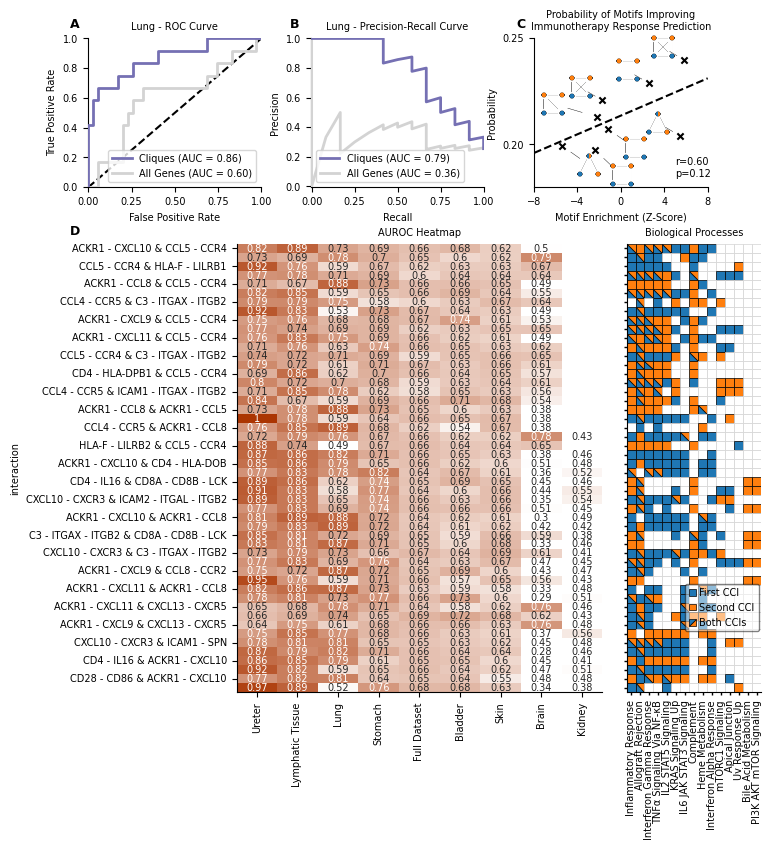

In [58]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns
from matplotlib.legend_handler import HandlerBase

from scipy.stats import pearsonr
import os
from PIL import Image
import pandas as pd

N_TOP = 30

# --- Settings ---
titlefs = 7
fs = 7
smallfs = 7
height = 0.8

# --- MOSAIC LAYOUT ---
fig = plt.figure(figsize=(7.08, 8.5), constrained_layout=False)

mosaic = [
    ["a", "b", "c"],
    ["d", "d", "e"],
]

ax_dict = fig.subplot_mosaic(
    mosaic,
    gridspec_kw={"width_ratios": [1, 1, 1.], "height_ratios": [1, 3], "wspace": 0., "hspace": 0.19}
)

axA = ax_dict["a"]
axB = ax_dict["b"]
axC = ax_dict["c"]
ax = ax_dict["d"]
ax_hm = ax_dict["e"]

# =========================
# PANEL A (ROC CURVE)
# =========================
cohort = 'lung'

fpr_cliques = roc_curves[cohort]['all_cliques']['fpr']
tpr_cliques = roc_curves[cohort]['all_cliques']['tpr']
auc_cliques = roc_curves[cohort]['all_cliques']['auc']

fpr_whole = roc_curves[cohort]['whole_transcriptome']['fpr']
tpr_whole = roc_curves[cohort]['whole_transcriptome']['tpr']
auc_whole = roc_curves[cohort]['whole_transcriptome']['auc']

color = cohort_colors.get(cohort, 'black')
title = cohort.replace('_', ' ').title()

axA.set_title(f"{title} - ROC Curve", fontsize=fs)

axA.set_xlabel("False Positive Rate", fontsize=fs)
axA.set_ylabel("True Positive Rate", fontsize=fs)

axA.plot([0, 1], [0, 1], color='k', linestyle="--")
axA.plot(fpr_cliques, tpr_cliques,
         label=f"Cliques (AUC = {auc_cliques:.2f})",
         color=color, lw=2, zorder=10)
axA.plot(fpr_whole, tpr_whole,
         label=f"All Genes (AUC = {auc_whole:.2f})",
         color='lightgray', lw=2, zorder=5)

axA.set_xlim(-0.005, 1)
axA.set_ylim(0, 1.005)

axA.legend(fontsize=fs)

axA.tick_params(axis='both', labelsize=fs)

axA.spines['top'].set_visible(False)
axA.spines['right'].set_visible(False)

# =========================
# PANEL B (PRECISION-RECALL)
# =========================
cohort = 'lung'

precision_cliques = pr_curves[cohort]['all_cliques']['precision']
recall_cliques = pr_curves[cohort]['all_cliques']['recall']
auc_cliques = pr_curves[cohort]['all_cliques']['auprc']

precision_whole = pr_curves[cohort]['whole_transcriptome']['precision']
recall_whole = pr_curves[cohort]['whole_transcriptome']['recall']
auc_whole = pr_curves[cohort]['whole_transcriptome']['auprc']

color = cohort_colors.get(cohort, 'black')
title = cohort.replace('_', ' ').title()

axB.set_title(f"{title} - Precision-Recall Curve", fontsize=fs)

axB.set_xlabel("Recall", fontsize=fs)
axB.set_ylabel("Precision", fontsize=fs)

axB.plot(recall_cliques, precision_cliques,
         label=f"Cliques (AUC = {auc_cliques:.2f})",
         color=color, lw=2, zorder=10)
axB.plot(recall_whole, precision_whole,
         label=f"All Genes (AUC = {auc_whole:.2f})",
         color='lightgray', lw=2, zorder=5)

axB.set_xlim(-0.005, 1.005)
axB.set_ylim(-0.005, 1.005)

axB.legend(fontsize=fs)

axB.tick_params(axis='both', labelsize=fs)

axB.spines['top'].set_visible(False)
axB.spines['right'].set_visible(False)

# =========================
# PANEL C (SHARP ICON VERSION)
# =========================

dpi = 300
img_dir = '/home/lnemati/pathway_crosstalk/data/motifs_icons/'
fs = fs

probs = (better.query('tissue != "full_dataset"').motif.value_counts() /
         crosstalkdf.query('tissue != "full_dataset"').motif.value_counts()).sort_values()

probs = probs.loc[motifs_z.index]
data = pd.DataFrame({'z': motifs_z, 'prob': probs})

r_value, p_value = pearsonr(probs, motifs_z)

axC.scatter(
    data['z'],
    data['prob'],
    color='black',
    marker='x',
    s=20,
    linewidths=1.5
)

axC.text(5, 0.185, f"r={r_value:.2f}\np={p_value:.2f}", fontsize=fs)

axC.set_xlim(-8, 8)
axC.set_ylim(0.18, 0.25)
axC.set_xticks([-8, -4, 0, 4, 8])
axC.set_yticks([0.2, 0.25])

axC.set_title('Probability of Motifs Improving\nImmunotherapy Response Prediction', fontsize=fs)
axC.set_xlabel('Motif Enrichment (Z-Score)', fontsize=fs)
axC.set_ylabel('Probability', fontsize=fs)

axC.spines['top'].set_visible(False)
axC.spines['right'].set_visible(False)
axC.tick_params(labelsize=fs)

axC.patch.set_alpha(0)

# regression
slope, intercept = np.polyfit(data['z'], data['prob'], 1)
x_ext = np.linspace(-8, 8, 200)
axC.plot(x_ext, slope * x_ext + intercept, '--', color='k', lw=1.5, zorder=-10)

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import os

# --- ICON PLACEMENT (NO RESIZING, NO figimage) ---
icon_zoom = 0.03  # tweak this (main control knob)

motif_positions = {
    '3_path': (data['z']['3_path']+2.5, data['prob']['3_path']-0.009),
    '4_cycle': (data['z']['4_cycle']+2.5, data['prob']['4_cycle']-0.012),
    '4_triangle_extra': (data['z']['4_triangle_extra']-4, data['prob']['4_triangle_extra']+0.006),
    '4_one_missing': (data['z']['4_one_missing']-2, data['prob']['4_one_missing']+0.006),
    '4_path': (data['z']['4_path']+2.5, data['prob']['4_path']-0.009),
    '4_no_crosstalk': (data['z']['4_no_crosstalk']-2, data['prob']['4_no_crosstalk']+0.006),
    '3_clique': (data['z']['3_clique']-2, data['prob']['3_clique']+0.006),
    '4_clique': (data['z']['4_clique']-2, data['prob']['4_clique']+0.006),
}

for motif, (x_pos, y_pos) in motif_positions.items():
    img_path = os.path.join(img_dir, f"{motif}.png")
    if not os.path.exists(img_path):
        continue

    im = Image.open(img_path)

    # IMPORTANT: keep original resolution
    imagebox = OffsetImage(im, zoom=icon_zoom, resample=True)

    ab = AnnotationBbox(
        imagebox,
        (x_pos, y_pos),
        frameon=False,
        box_alignment=(0.5, 0.5),
        zorder=6
    )

    axC.add_artist(ab)

    # =========================
    # CONNECTOR (TRIMMED LINE)
    # =========================
    draw_frac = 0.33  # <-- NEW CONTROL (0 = full line, 1 = no line)

    x0, y0 = motifs_z.loc[motif], probs.loc[motif]
    x1, y1 = x_pos, y_pos

    dx, dy = x1 - x0, y1 - y0
    dist = np.hypot(dx, dy)

    if dist > 0:
        dxn, dyn = dx / dist, dy / dist

        # fraction removed from BOTH ends
        trim = (1 - draw_frac) / 2

        x_start = x0 + dxn * dist * trim
        y_start = y0 + dyn * dist * trim

        x_end = x1 - dxn * dist * trim
        y_end = y1 - dyn * dist * trim

        axC.plot(
            [x_start, x_end],
            [y_start, y_end],
            color='k',
            lw=0.3,
            zorder=-5
        )

# =========================
# MAIN HEATMAP (AUROC)
# =========================
order_tissues = aurocs_df.mean(axis=0).sort_values(ascending=False).index
order_interactions = aurocs_df.mean(axis=1).sort_values(ascending=False).index
aurocs_df_subset = aurocs_df.loc[order_interactions, order_tissues]

N = 15
hallmark_counts = (heatmap_df != 0).sum(axis=0)
top_hallmarks = hallmark_counts.sort_values(ascending=False).head(N).index
top_heatmap_df = heatmap_df[top_hallmarks]
top_heatmap_df = top_heatmap_df.loc[aurocs_df_subset.index]
hallmark_matrix = top_heatmap_df.values

vmin, vmax = 0.5, 1.0
cmap = mcolors.LinearSegmentedColormap.from_list("white_to_color", ["white", tcolor])

sns.heatmap(
    aurocs_df_subset,
    annot=True,
    cmap=cmap,
    cbar=False,
    ax=ax,
    vmin=vmin,
    vmax=vmax,
    annot_kws={"fontsize": fs}
)

ax.set_xlabel(ax.get_xlabel(), fontsize=fs)
ax.set_ylabel(ax.get_ylabel(), fontsize=fs)

#labels = [t.get_text().replace(" ", "") for t in ax.get_yticklabels()]
#ax.set_yticklabels(labels, fontsize=fs)

ax.set_title('AUROC Heatmap', fontsize=titlefs)

# =========================
# PANEL E (BIOLOGICAL PROCESS HEATMAP)
# =========================
ax_hm.set_yticks([])
ax_hm.set_xticks(np.arange(hallmark_matrix.shape[1]) + 0.5)
ax_hm.set_xticklabels(top_heatmap_df.columns, rotation=90, fontsize=fs)

ax_hm.set_yticks(0.5 + np.arange(hallmark_matrix.shape[0] + 1), minor=True)
#ax_hm.tick_params(which='minor', bottom=False, left=False, length=2, width=1)
ax_hm.tick_params(axis='both', which='both', bottom=True, top=False, length=2, width=1)

for i in range(hallmark_matrix.shape[0]):
    for j in range(hallmark_matrix.shape[1]):
        val = hallmark_matrix[i, j]
        if val == 0:
            rect = patches.Rectangle((j, i), 1, 1,
                                     facecolor='white',
                                     edgecolor='lightgray',
                                     linewidth=0.5)
            ax_hm.add_patch(rect)
        elif val == 1:
            rect = patches.Rectangle((j, i), 1, 1,
                                     facecolor='C0',
                                     edgecolor='k',
                                     linewidth=0.5)
            ax_hm.add_patch(rect)
        elif val == 2:
            rect = patches.Rectangle((j, i), 1, 1,
                                     facecolor='C1',
                                     edgecolor='k',
                                     linewidth=0.5)
            ax_hm.add_patch(rect)
        elif val == 3:
            tri1 = patches.Polygon([(j, i), (j, i + 1), (j + 1, i + 1)],
                                   facecolor='C0', edgecolor='k', linewidth=0.5)
            tri2 = patches.Polygon([(j, i), (j + 1, i), (j + 1, i + 1)],
                                   facecolor='C1', edgecolor='k', linewidth=0.5)
            ax_hm.add_patch(tri1)
            ax_hm.add_patch(tri2)

ax_hm.set_xlim(0, hallmark_matrix.shape[1])
ax_hm.set_ylim(hallmark_matrix.shape[0], 0)
ax_hm.set_aspect('equal', adjustable='box')
ax_hm.set_title('Biological Processes', fontsize=titlefs)

class HandlerSplitSquare(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        tri1 = patches.Polygon([[xdescent, ydescent],
                                [xdescent, ydescent + height],
                                [xdescent + width, ydescent + height]],
                               facecolor='C0', edgecolor='k', linewidth=0.5, transform=trans)
        tri2 = patches.Polygon([[xdescent, ydescent],
                                [xdescent + width, ydescent],
                                [xdescent + width, ydescent + height]],
                               facecolor='C1', edgecolor='k', linewidth=0.5, transform=trans)
        return [tri1, tri2]

patch_c0 = patches.Rectangle((0, 0), 1, 1, facecolor='C0', edgecolor='k', linewidth=0.5)
patch_c1 = patches.Rectangle((0, 0), 1, 1, facecolor='C1', edgecolor='k', linewidth=0.5)
split_square_handle = object()

ax_hm.legend(
    handles=[patch_c0, patch_c1, split_square_handle],
    labels=['First CCI', 'Second CCI', 'Both CCIs'],
    handler_map={split_square_handle: HandlerSplitSquare()},
    loc='lower center',
    bbox_to_anchor=(0.71, 0.125),
    fontsize=fs,
    ncol=1,
    frameon=True,
    facecolor='white',
    framealpha=0.5,
    edgecolor='black',
    handlelength=0.65,
    handleheight=0.65,
    handletextpad=0.4,
)

# =========================
# CLEANUP (only top/right spines hidden)
# =========================
for axx in ax_dict.values():
    for side, spine in axx.spines.items():
        if side in ["top", "right"]:
            spine.set_visible(False)
        else:
            spine.set_visible(True)
    axx.tick_params(labelsize=fs)

# =========================
# RESTORE LEFT SHIFT / SPACE UTILIZATION
# =========================
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

pos_a = axA.get_position()
pos_b = axB.get_position()
pos_c = axC.get_position()

tb_d = ax.get_tightbbox(renderer).transformed(fig.transFigure.inverted())

left_edge = tb_d.x0 + 0.1*(pos_c.x1 - tb_d.x0)
right_edge = pos_c.x1 - 0.1*(pos_c.x1 - tb_d.x0)

gap = 0.07
w = (right_edge - left_edge - 2 * gap) / 3

axA.set_position([left_edge, pos_a.y0, w, pos_a.height])
axB.set_position([left_edge + w + gap, pos_b.y0, w, pos_b.height])
axC.set_position([left_edge + 2*(w + gap), pos_c.y0, w, pos_c.height])

fig.text(-0.11, 0.903, "A", fontsize=fs+2, fontweight='bold', va='top')
fig.text(0.2, 0.903, "B", fontsize=fs+2, fontweight='bold', va='top')
fig.text(0.52, 0.903, "C", fontsize=fs+2, fontweight='bold', va='top')

fig.text(-0.11, 0.66, "D", fontsize=fs+2, fontweight='bold', va='top')
#fig.text(0.52, 0.66, "E", fontsize=fs+2, fontweight='bold', va='top')

#for label in ax.get_xticklabels():
#    label.set_rotation(45)
#    label.set_ha('right')
#    
#for label in ax_hm.get_xticklabels():
#    label.set_rotation(45)
#    label.set_ha('right')

# -----------------------------
# Save
# -----------------------------
name = 'S8'
figures_dir = '/home/lnemati/pathway_crosstalk/results/figures/new_figures'
os.makedirs(os.path.join(figures_dir, name), exist_ok=True)

plt.savefig(os.path.join(figures_dir, name, name) + '.pdf', bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(figures_dir, name, name) + '.png', bbox_inches='tight', dpi=300)

plt.show()